# Tahap 1 : Business Understanding

Proyek ini bertujuan untuk membantu pelanggan layanan telekomunikasi memilih paket yang sesuai dengan kebutuhan mereka. Banyaknya variasi produk dan kurangnya rekomendasi personal membuat pelanggan sering kesulitan menentukan pilihan. Penyedia layanan juga belum memiliki sistem yang mampu menganalisis perilaku pengguna untuk memberikan penawaran yang relevan.

Melalui platform Paketin, model machine learning dibangun untuk membaca pola konsumsi pelanggan dan memprediksi kategori penawaran produk yang paling sesuai. Model ini akan diintegrasikan ke backend website sebagai sistem rekomendasi.

## Tujuan Proyek
- Mengidentifikasi pola penggunaan pelanggan.
- Mengklasifikasikan pelanggan ke kategori penawaran produk.
- Menghasilkan rekomendasi paket yang personal dan akurat.

## Pertanyaan Penelitian
- Seberapa akurat model dalam memahami perilaku pelanggan?


# Tahap 2 : Data Understanding

Pada tahap ini dilakukan proses eksplorasi awal terhadap dataset untuk memahami struktur dan karakteristik data yang akan digunakan untuk membangun model. Proses ini mencakup pengecekan jumlah baris dan kolom, tipe data setiap fitur, distribusi target label, serta identifikasi potensi permasalahan seperti missing value atau ketidakseimbangan kelas.

Melalui tahap ini diperoleh gambaran awal mengenai kualitas dan pola data sehingga dapat ditentukan langkah pra-proses yang diperlukan sebelum masuk ke tahap pemodelan.

## 2.1 Lakukan import segala library yang diperlukan

Pada tahap awal, dilakukan import berbagai library yang diperlukan, mulai dari utilitas dasar seperti `pandas` dan `numpy`, library visualisasi seperti `matplotlib` dan `seaborn`, serta library preprocessing, modeling, evaluasi, dan hyperparameter tuning dari scikit-learn dan XGBoost. Selain itu, digunakan juga `SMOTE` untuk menangani ketidakseimbangan kelas, serta `joblib` untuk menyimpan model.

In [ ]:
# Utilities dasar
import math
import numpy as np
import pandas as pd

# Visualisasi
import matplotlib.pyplot as plt
import seaborn as sns

# Utilities Colab (load dataset)
from google.colab import drive
from io import StringIO

# Preprocessing
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OrdinalEncoder
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE
from sklearn.compose import ColumnTransformer

# Pemilihan fitur
from sklearn.feature_selection import mutual_info_classif

# Modeling
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from xgboost import callback

# Evaluasi model
from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.model_selection import cross_val_score

# Hyperparameter tuning
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint
from scipy.stats import uniform

# Menyimpan / memuat model
import joblib


## 2.2 Load Dataset

Dataset yang digunakan berasal dari pemberian Use Case Owner dan telah diunduh kemudian disimpan di Google Drive. Sebelum dibaca sebagai DataFrame, data dibersihkan terlebih dahulu dari tanda kutip berlebih untuk memastikan formatnya sesuai. Setelah dataset berhasil dimuat, dilakukan inspeksi awal menggunakan `df.head()` untuk melihat struktur data, nama kolom, serta contoh nilai dari setiap fitur.


In [ ]:
# Lakukan mounting drive untuk load dataset
drive.mount('/content/drive/')

Mounted at /content/drive/


In [ ]:
# Lakukan load dataset dan tampilkan hasilnya
with open("/content/drive/MyDrive/Asah/Asah - Capstone/Dataset/ac-01_telco_customer_behavior_mock_data - ac-01_telco_customer_behavior_mock_data.csv", "r") as f:
    lines = f.readlines()

# Hapus tanda kutip dan gabungkan kembali
clean_text = "\n".join([line.strip().strip('"') for line in lines])

# Baca ulang dari string yang sudah bersih
df = pd.read_csv(StringIO(clean_text), sep=",")
df.head()

,customer_id,plan_type,device_brand,avg_data_usage_gb,pct_video_usage,avg_call_duration,sms_freq,monthly_spend,topup_freq,travel_score,complaint_count,target_offer
0,C00001,Prepaid,Realme,1.50,0.804146,7.98,13,70000.0,4,0.284419,0,General Offer
1,C00002,Postpaid,Vivo,1.09,0.107686,9.56,9,63000.0,3,0.115086,0,General Offer
2,C00003,Postpaid,Xiaomi,3.24,0.313894,4.61,13,89000.0,7,0.402998,0,General Offer
3,C00004,Prepaid,Apple,5.32,0.420158,6.96,8,67000.0,4,0.302169,0,General Offer
4,C00005,Prepaid,Huawei,1.91,0.251638,11.01,21,72000.0,5,0.487911,0,General Offer


## 2.3 Melihat Karakteristik Dasar Dataset

Pada bagian ini dilakukan beberapa pengecekan penting:

- **Struktur Data (`df.info()`):** melihat tipe data setiap kolom dan memastikan jumlah entri.  
- **Statistik Deskriptif (`df.describe()`):** memahami rentang nilai, rata-rata, variasi, dan karakteristik fitur numerik.  
- **Statistik Fitur Kategorikal (`df.describe(include='object')`):** melihat jumlah kategori unik dan frekuensi masing-masing kategori.  
- **Missing Value (`df.isna().sum()`):** memastikan apakah terdapat nilai kosong yang perlu ditangani.  
- **Duplikasi (`df.duplicated().sum()`):** mengecek apakah dataset memiliki baris duplikat.  
- **Profil per Kategori Target:** dilakukan analisis deskriptif untuk setiap kategori `target_offer` untuk memahami pola penggunaan berdasarkan kelompok target.

In [ ]:
# Melihat info statistik dari dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   customer_id        10000 non-null  object 
 1   plan_type          10000 non-null  object 
 2   device_brand       10000 non-null  object 
 3   avg_data_usage_gb  10000 non-null  float64
 4   pct_video_usage    10000 non-null  float64
 5   avg_call_duration  10000 non-null  float64
 6   sms_freq           10000 non-null  int64  
 7   monthly_spend      10000 non-null  float64
 8   topup_freq         10000 non-null  int64  
 9   travel_score       10000 non-null  float64
 10  complaint_count    10000 non-null  int64  
 11  target_offer       10000 non-null  object 
dtypes: float64(5), int64(3), object(4)
memory usage: 937.6+ KB


Berdasarkan hasil `df.info()`, dataset memiliki 10.000 baris dan 12 kolom, dengan seluruh kolom menunjukkan nilai non-null. Hal ini berarti tidak terdapat missing value pada dataset, sehingga data dapat langsung digunakan tanpa proses imputasi.

Tipe data pada dataset terdiri dari:

- **4 kolom bertipe object (kategorikal):**
  - customer_id
  - plan_type
  - device_brand
  - target_offer

- **5 kolom bertipe float64 (kontinu):**
  - avg_data_usage_gb
  - pct_video_usage
  - avg_call_duration
  - monthly_spend
  - travel_score

- **3 kolom bertipe int64 (diskrit):**
  - sms_freq
  - topup_freq
  - complaint_count

Struktur data ini menunjukkan bahwa dataset berisi kombinasi fitur kategorikal dan numerik yang relevan untuk proses klasifikasi. Tidak adanya missing value mempermudah tahap preprocessing, sehingga fokus dapat diarahkan pada encoding, normalisasi fitur numerik, serta analisis ketidakseimbangan kelas pada target target_offer.


In [ ]:
# Melihat deskripsi statistik numerik dari dataset
df.describe()

,avg_data_usage_gb,pct_video_usage,avg_call_duration,sms_freq,monthly_spend,topup_freq,travel_score,complaint_count
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,5.958883,0.402639,9.971357,15.010800,109776.500000,2.986600,0.282441,0.492600
std,4.192909,0.195741,4.954993,3.872775,46237.321903,1.709828,0.158366,0.704127
min,0.030000,0.000000,-8.370000,4.000000,-13000.000000,0.000000,0.003376,0.000000
25%,2.870000,0.265290,6.650000,12.000000,78000.000000,2.000000,0.158775,0.000000
50%,4.990000,0.400116,10.020000,15.000000,102000.000000,3.000000,0.261206,0.000000
75%,8.040000,0.535161,13.320000,18.000000,135000.000000,4.000000,0.385656,1.000000
max,39.020000,1.000000,27.770000,31.000000,450000.000000,12.000000,0.854814,5.000000


Berdasarkan hasil `df.describe()`, berikut ringkasan karakteristik untuk fitur-fitur numerik:

**avg_data_usage_gb**  
  - Rata-rata penggunaan data sekitar 5.96 GB per bulan.  
  - Standar deviasi 4.19 menunjukkan variasi penggunaan yang besar.  
  - Nilai maksimum mencapai 39 GB, menandakan pengguna dengan aktivitas internet sangat tinggi.

**pct_video_usage**  
  - Rata-rata konsumsi video sebesar 40%.  
  - Median mendekati mean, menandakan distribusi relatif simetris.  
  - Rentang nilai 0–1 sesuai representasi proporsi.

**avg_call_duration**  
  - Rata-rata durasi panggilan adalah 9.97 menit.  
  - Terdapat nilai minimum -8.37 yang merupakan anomali dan berpotensi menjadi outlier.  
  - Nilai maksimum 27.77 masih wajar untuk durasi panggilan.

**sms_freq**  
  - Pengguna rata-rata mengirim sekitar 15 SMS per bulan.  
  - Rentang nilai 4 hingga 31 menunjukkan penggunaan SMS yang cukup normal.

**monthly_spend**  
  - Rata-rata pengeluaran adalah 109.776.  
  - Standar deviasi besar (46.237), menunjukkan variasi tinggi antar pengguna.  
  - Nilai minimum -13.000 adalah nilai tidak logis sehingga perlu penanganan.


**topup_freq**  
  - Rata-rata frekuensi top-up adalah 2.98 kali per bulan.  
  - Nilai maksimum 12 kali menunjukkan sebagian pengguna sangat aktif mengisi ulang.


**travel_score**  
  - Rata-rata skor mobilitas adalah 0.28.  
  - Rentang nilai 0.003–0.85 menunjukkan sebagian besar pengguna memiliki mobilitas rendah hingga sedang.

**complaint_count**  
  - Rata-rata jumlah keluhan per pengguna adalah 0.49.  
  - Mayoritas pengguna tidak memiliki keluhan (median = 0).  
  - Nilai maksimum 5 menunjukkan ada sebagian kecil pengguna yang sering komplain.


Kesimpulan:  
- Tidak terdapat missing value, namun beberapa anomali ditemukan, terutama pada avg_call_duration dan monthly_spend.  
- Variasi penggunaan, pengeluaran, dan aktivitas cukup tinggi, menunjukkan keberagaman perilaku pelanggan.  
- Rentang nilai yang berbeda-beda menunjukkan perlunya normalisasi atau standardisasi sebelum modeling.  
- Distribusi complaint_count dan travel_score condong ke nilai rendah sehingga bersifat skewed.


In [ ]:
# Melihat deskripsi statistik non-numerik dari dataset
df.describe(include='object')

,customer_id,plan_type,device_brand,target_offer
count,10000,10000,10000,10000
unique,10000,2,7,9
top,C09984,Prepaid,Realme,General Offer
freq,1,6108,1509,6070


Berdasarkan output `df.describe(include='object')`, berikut interpretasinya:

**customer_id**  
  - Memiliki 10.000 nilai unik, sesuai jumlah baris dataset.  
  - Nilai paling sering muncul hanya 1 kali, artinya tidak ada duplikasi.  
  - Kolom ini hanya berfungsi sebagai identifier dan tidak digunakan sebagai fitur dalam model.


**plan_type**  
  - Memiliki 2 kategori, yaitu Prepaid dan Postpaid.  
  - Kategori paling dominan adalah Prepaid dengan 6108 data.  
  - Distribusi tidak seimbang, namun masih dapat ditangani dengan encoding sederhana.


**device_brand**  
  - Terdapat 7 merek perangkat berbeda dalam dataset.  
  - Merek paling banyak digunakan adalah Realme dengan 1509 pengguna.  
  - Keragaman ini dapat memberikan informasi tambahan mengenai pola penggunaan.


**target_offer**  
  - Memiliki 9 kategori sebagai label yang akan diprediksi.  
  - Kategori terbanyak adalah General Offer dengan 6070 data.  
  - Distribusi sangat tidak seimbang sehingga diperlukan penanganan imbalance seperti SMOTE.


Kesimpulan:  
  - Variabel kategorikal memiliki keragaman yang cukup baik, kecuali plan_type yang hanya memiliki 2 kategori.  
  - Kolom target_offer sangat imbalance sehingga harus ditangani sebelum modeling.  
  - customer_id tidak relevan untuk prediksi dan akan di-drop pada proses preprocessing.


In [ ]:
# Melihat jumlah nilai hilang
print("Jumlah nilai hilang : ")
df.isna().sum()

Jumlah nilai hilang : 


,0
customer_id,0
plan_type,0
device_brand,0
avg_data_usage_gb,0
pct_video_usage,0
avg_call_duration,0
sms_freq,0
monthly_spend,0
topup_freq,0
travel_score,0


Berdasarkan output dari perintah `df.isna().sum()`, dapat disimpulkan bahwa seluruh kolom memiliki nilai 0 untuk jumlah missing value. Artinya, tidak terdapat nilai kosong (NaN) pada dataset ini. Dengan demikian, dataset dapat dikatakan bersih dari missing value dan tidak memerlukan proses imputasi pada tahap preprocessing.

In [ ]:
# Melihat jumlah nilai duplikat
print("Jumlah nilai duplikat : ")
df.duplicated().sum()

Jumlah nilai duplikat : 


np.int64(0)

Berdasarkan output dari perintah `df.duplicated().sum()`, jumlah baris duplikat adalah 0. Hal ini menunjukkan bahwa tidak ada data yang terduplikasi di dalam dataset. Dengan demikian, tidak diperlukan proses penghapusan duplikasi pada tahap preprocessing.

In [ ]:
# Melakukan analisis profil per kategori target(target_offer)
print('Analisis Profil per Kategori Target Offer\n')

# Looping akan menampilkan tabel terformat secara otomatis
for offer_type in df['target_offer'].unique():
    print(f"\n--- Profil untuk Target Offer: {offer_type} ---")
    subset_df = df[df['target_offer'] == offer_type]

    # Memanggil objek DataFramenya
    print("\nStatistik Deskriptif untuk Fitur Numerik:")
    display(subset_df.describe())

    print("\nStatistik Deskriptif untuk Fitur Kategorikal:")
    display(subset_df.describe(include='object'))

Analisis Profil per Kategori Target Offer


--- Profil untuk Target Offer: General Offer ---

Statistik Deskriptif untuk Fitur Numerik:


,avg_data_usage_gb,pct_video_usage,avg_call_duration,sms_freq,monthly_spend,topup_freq,travel_score,complaint_count
count,6070.000000,6070.000000,6070.000000,6070.000000,6070.000000,6070.000000,6070.000000,6070.000000
mean,4.782153,0.375200,9.883402,14.940692,97862.602965,2.933937,0.276499,0.323558
std,3.326567,0.183259,4.865311,3.780531,35474.518902,1.710681,0.149935,0.467872
min,0.040000,0.000000,-8.370000,4.000000,40000.000000,0.000000,0.003376,0.000000
25%,2.530000,0.251414,6.610000,12.000000,75000.000000,2.000000,0.158795,0.000000
50%,4.050000,0.375952,9.995000,15.000000,92000.000000,3.000000,0.258348,0.000000
75%,6.037500,0.492993,13.250000,17.000000,112000.000000,4.000000,0.378547,1.000000
max,30.660000,1.000000,26.840000,31.000000,372000.000000,10.000000,0.699528,1.000000



Statistik Deskriptif untuk Fitur Kategorikal:


,customer_id,plan_type,device_brand,target_offer
count,6070,6070,6070,6070
unique,6070,2,7,1
top,C10000,Prepaid,Realme,General Offer
freq,1,3674,1089,6070



--- Profil untuk Target Offer: Top-up Promo ---

Statistik Deskriptif untuk Fitur Numerik:


...

,customer_id,plan_type,device_brand,target_offer
count,68,68,68,68
unique,68,1,7,1
top,C00070,Postpaid,Samsung,Voice Bundle
freq,1,68,11,68



--- Profil untuk Target Offer: Family Plan Offer ---

Statistik Deskriptif untuk Fitur Numerik:


,avg_data_usage_gb,pct_video_usage,avg_call_duration,sms_freq,monthly_spend,topup_freq,travel_score,complaint_count
count,81.000000,81.000000,81.000000,81.000000,81.000000,81.000000,81.000000,81.000000
mean,6.740741,0.399032,9.116296,22.962963,127209.876543,2.814815,0.272608,0.543210
std,3.292532,0.177195,4.819022,2.076322,31814.193393,1.628735,0.148315,0.742452
min,2.090000,0.057310,-3.330000,21.000000,101000.000000,0.000000,0.020602,0.000000
25%,4.730000,0.255380,5.440000,21.000000,110000.000000,2.000000,0.161751,0.000000
50%,6.030000,0.421613,9.670000,23.000000,116000.000000,3.000000,0.262608,0.000000
75%,7.400000,0.497672,12.480000,24.000000,130000.000000,4.000000,0.356879,1.000000
max,19.080000,0.825942,19.740000,30.000000,300000.000000,8.000000,0.670660,3.000000



Statistik Deskriptif untuk Fitur Kategorikal:


,customer_id,plan_type,device_brand,target_offer
count,81,81,81,81
unique,81,1,7,1
top,C00272,Postpaid,Realme,Family Plan Offer
freq,1,81,21,81


Berikut adalah ringkasan hasil analisis deskriptif berdasarkan masing-masing kategori target_offer. Analisis ini membantu memahami pola perilaku pelanggan di setiap segmen penawaran.

**General Offer**  
- Merupakan kategori terbesar dengan 6070 pengguna.  
- Rata-rata penggunaan data berada pada level menengah (sekitar 4.78 GB).  
- Mayoritas menggunakan plan Prepaid dengan perangkat Realme.  
- Pengeluaran bulanan sekitar 97 ribu.  
- Tingkat keluhan sangat rendah (median = 0).  


**Top-up Promo**  
- Total 370 pengguna.  
- Penggunaan data cenderung rendah (1.9 GB).  
- Frekuensi top-up lebih tinggi dibanding kategori lain (mean = 4.22).  
- Dominan pengguna Prepaid dan merek Oppo.  
- Konsumsi video relatif seragam (mean 0.39).  


**Device Upgrade Offer**  
- Total 1502 pengguna.  
- Penggunaan data tinggi (rata-rata 9.59 GB).  
- Pengeluaran bulanan paling tinggi kedua setelah Data Booster.  
- Cenderung pengguna dengan perangkat Xiaomi dan Realme.  
- Cocok untuk segmen pengguna aktif yang kemungkinan siap upgrade perangkat.  

**Data Booster**  
- Total 797 pengguna.  
- Pengguna dengan konsumsi data sangat tinggi (mean 11.63 GB).  
- Persentase konsumsi video juga tertinggi (mean 0.63).  
- Pengeluaran bulanan rata-rata 166 ribu.  
- Mayoritas plan Prepaid, perangkat Realme paling dominan.  
- Cukup potensial sebagai sasaran penjualan paket booster.  

**Retention Offer**  
- Total 761 pengguna.  
- Pengeluaran bulanan rendah hingga sedang (mean 84 ribu).  
- Tingkat keluhan tertinggi (mean = 1.87).  
- Memiliki beberapa nilai anomali seperti monthly_spend negatif.  
- Penggunaan data cenderung rendah hingga menengah.  
- Cocok untuk strategi retensi pelanggan yang berisiko churn.  

**Streaming Partner Pack**  
- Total 258 pengguna.  
- Memiliki penggunaan data stabil (mean ~6.20 GB), tetapi konsumsi video sangat tinggi (mean 0.70).  
- Pengeluaran sekitar 105 ribu per bulan.  
- Didominasi perangkat Realme.  
- Cenderung cocok untuk paket streaming bundling.  


**Roaming Pass**  
- Total 93 pengguna.  
- Memiliki travel_score sangat tinggi (mean 0.75).  
- Penggunaan data moderat (mean ~5.27 GB).  
- Pengeluaran ~105 ribu per bulan.  
- Dominan perangkat Oppo.  
- Sangat jelas mewakili segmen sering bepergian ke luar wilayah.  


**Voice Bundle**  
- Total 68 pengguna.  
- Durasi panggilan sangat tinggi (mean 22 menit).  
- Penggunaan data rendah hingga menengah.  
- Sebagian besar menggunakan perangkat Samsung dan plan Postpaid.  
- Sangat sesuai untuk paket telepon atau voice add-on.  


**Family Plan Offer**  
- Total 81 pengguna.  
- SMS freq sangat tinggi (mean 22), sesuai pola komunikasi keluarga.  
- Penggunaan data menengah (6.74 GB).  
- Pengeluaran sekitar 127 ribu.  
- Mayoritas pengguna Postpaid dengan perangkat Realme.  
- Cocok untuk paket keluarga yang mencakup data, voice, dan SMS.  

Kesimpulan  
- Setiap kategori target_offer memiliki pola yang berbeda sehingga dapat dibedakan cukup jelas oleh model.  
- Kategori General Offer adalah mayoritas sehingga data imbalance signifikan.  
- Anomali muncul di beberapa kategori, terutama nilai negatif pada monthly_spend dan avg_call_duration.  
- Perilaku pelanggan sangat bervariasi, mendukung penggunaan model klasifikasi multiklas.  


## 2.4 Melakukan Fase EDA

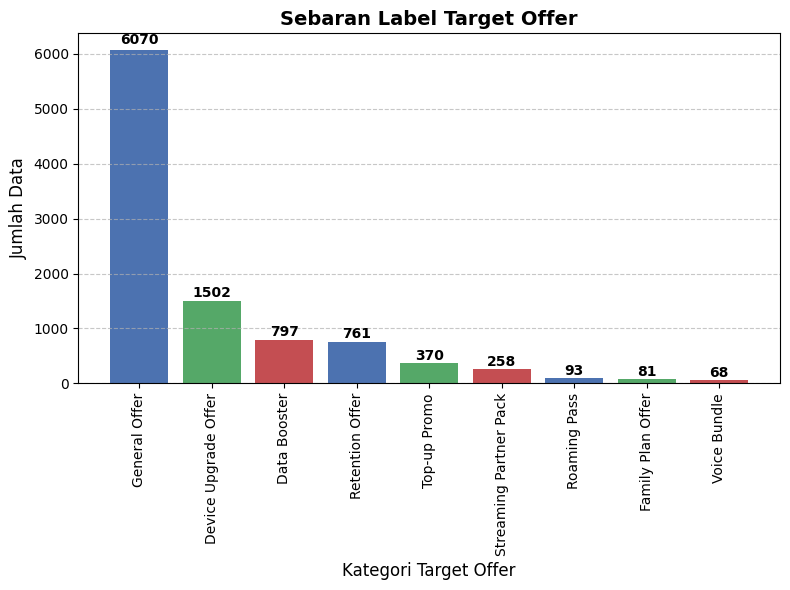

In [ ]:
# Melihat sebaran jumlah label data
value_counts = df['target_offer'].value_counts()

plt.figure(figsize=(8, 6))
bars = plt.bar(value_counts.index, value_counts.values, color=['#4C72B0', '#55A868', '#C44E52'])
plt.title('Sebaran Label Target Offer', fontsize=14, fontweight='bold')
plt.xlabel('Kategori Target Offer', fontsize=12)
plt.ylabel('Jumlah Data', fontsize=12)
plt.xticks(rotation=90)
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Tambahkan angka di atas tiap bar
for bar in bars:
    yval = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        yval + (0.01 * yval),
        int(yval),
        ha='center', va='bottom', fontsize=10, fontweight='bold'
    )

plt.tight_layout()
plt.show()


Visualisasi menunjukkan bahwa distribusi kelas pada variabel target_offer sangat tidak seimbang. Kategori General Offer mendominasi dengan 6070 data, jauh lebih besar dibanding kelas lainnya. Segmen besar berikutnya adalah Device Upgrade Offer (1502), Data Booster (797), dan Retention Offer (761). Sementara kategori lain seperti Roaming Pass (93), Family Plan Offer (81), dan Voice Bundle (68) memiliki jumlah sampel yang sangat kecil.

Ketidakseimbangan ini berpotensi menyebabkan model lebih bias terhadap kelas mayoritas, sehingga diperlukan penanganan seperti class weighting, resampling, atau pemilihan algoritma yang lebih robust terhadap class imbalance.


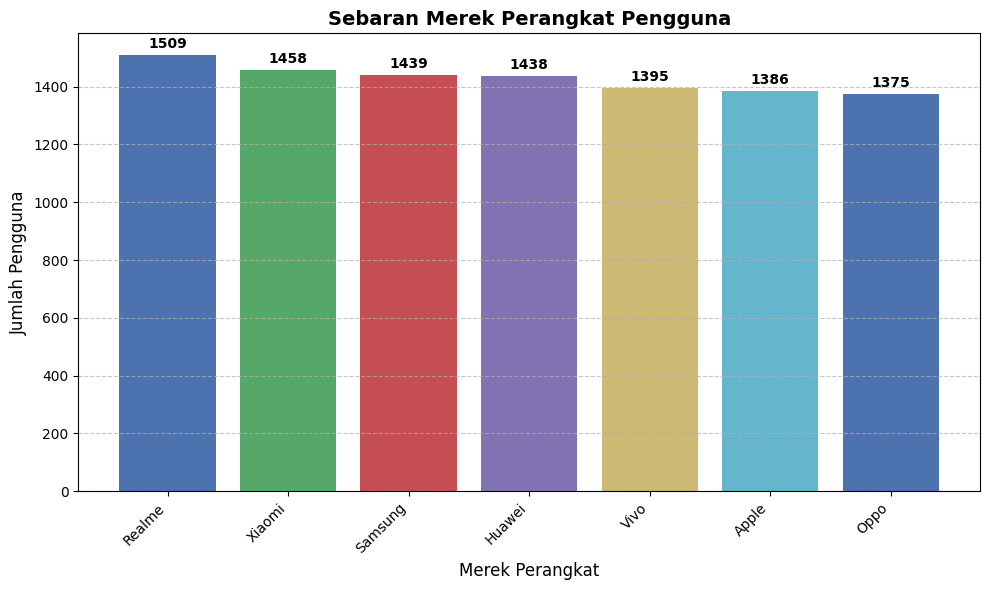

In [ ]:
# Menampilkan barplot untuk merk perangkat dari pengguna
# Melihat sebaran jumlah brand perangkat
value_counts = df['device_brand'].value_counts()

plt.figure(figsize=(10, 6))
bars = plt.bar(value_counts.index, value_counts.values, color=['#4C72B0', '#55A868', '#C44E52', '#8172B2', '#CCB974', '#64B5CD'])
plt.title('Sebaran Merek Perangkat Pengguna', fontsize=14, fontweight='bold')
plt.xlabel('Merek Perangkat', fontsize=12)
plt.ylabel('Jumlah Pengguna', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Tambahkan angka di atas tiap batang
for bar in bars:
    yval = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        yval + (0.01 * yval),
        int(yval),
        ha='center', va='bottom', fontsize=10, fontweight='bold'
    )

plt.tight_layout()
plt.show()

Grafik menunjukkan bahwa distribusi merek perangkat pengguna relatif merata di seluruh kategori. Realme merupakan merek dengan jumlah pengguna terbanyak (1509), diikuti oleh Xiaomi (1458), Samsung (1439), Huawei (1438), Vivo(1395), Apple(1386), Oppo(1375).

Sebaran yang merata ini mengindikasikan bahwa tidak ada dominasi yang terlalu besar dari satu merek tertentu. Hal ini bermanfaat bagi model karena tidak memunculkan bias kuat terhadap brand tertentu dan memungkinkan analisis perilaku pengguna yang lebih seimbang di seluruh jenis perangkat.

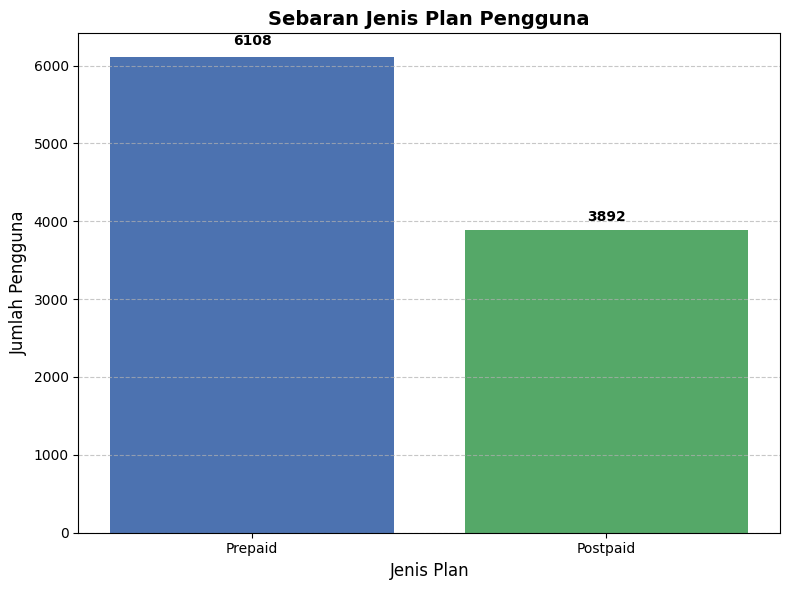

In [ ]:
# Menampilkan barplot untuk jenis plan dari pengguna
# Melihat sebaran jenis plan pengguna
value_counts = df['plan_type'].value_counts()

plt.figure(figsize=(8, 6))
bars = plt.bar(
    value_counts.index,
    value_counts.values,
    color=['#4C72B0', '#55A868']
)

plt.title('Sebaran Jenis Plan Pengguna', fontsize=14, fontweight='bold')
plt.xlabel('Jenis Plan', fontsize=12)
plt.ylabel('Jumlah Pengguna', fontsize=12)
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Tambahkan angka di atas tiap batang
for bar in bars:
    yval = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        yval + (0.02 * yval),
        int(yval),
        ha='center', va='bottom', fontsize=10, fontweight='bold'
    )

plt.tight_layout()
plt.show()

Visualisasi menunjukkan bahwa mayoritas pengguna berada pada kategori Prepaid dengan total 6108 pengguna. Sementara itu, pengguna Postpaid berjumlah 3892 pengguna.

Kondisi ini menegaskan bahwa sebagian besar pelanggan layanan telekomunikasi dalam dataset lebih memilih layanan prabayar.

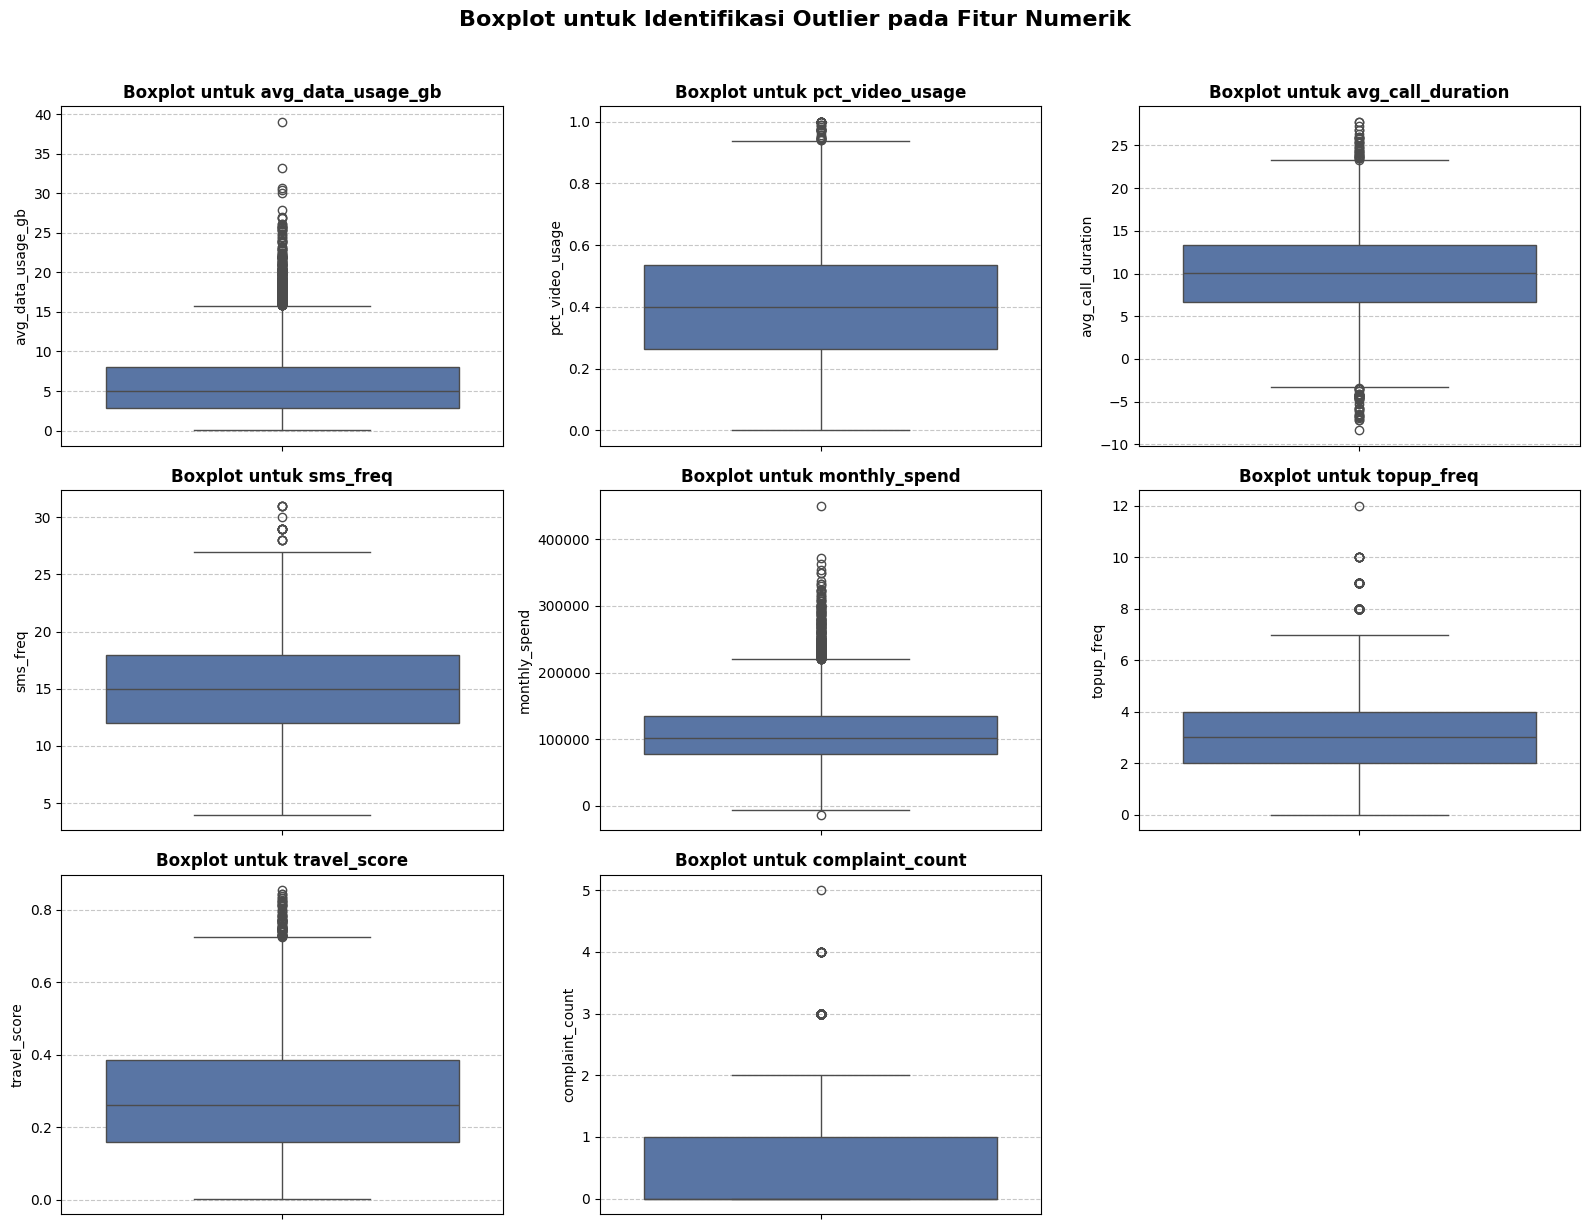

In [ ]:
# Membuat grafik boxplot untuk identifikasi outlier
# Pilih kolom numerik
numerical_cols = df.select_dtypes(include=np.number).columns

# Tentukan jumlah kolom per baris
cols_per_row = 3
n_cols = cols_per_row
n_rows = math.ceil(len(numerical_cols) / n_cols)

# Buat grid figure
fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 4 * n_rows))
axes = axes.flatten()

# Looping setiap kolom numerik dan plot ke subplot
for i, col in enumerate(numerical_cols):
    sns.boxplot(y=df[col], ax=axes[i], color='#4C72B0')
    axes[i].set_title(f'Boxplot untuk {col}', fontsize=12, fontweight='bold')
    axes[i].grid(axis='y', linestyle='--', alpha=0.7)

# Hilangkan axis kosong untuk menghapus sisa ruang dalam baris
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

# Buat Title
fig.suptitle('Boxplot untuk Identifikasi Outlier pada Fitur Numerik',
             fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

Dari visualisasi boxplot pada seluruh fitur numerik, ditemukan beberapa pola penting terkait keberadaan outlier dan kualitas data:

- **avg_data_usage_gb**  
  Banyak nilai ekstrem pada bagian atas, menunjukkan adanya pengguna dengan konsumsi data jauh di atas mayoritas. Distribusi bersifat right-skewed.

- **pct_video_usage**

  Hampir tidak memiliki outlier signifikan. Nilainya berada di rentang 0–1 sesuai proporsi.

- **avg_call_duration**  

  Terlihat outlier termasuk nilai negatif yang tidak logis. Nilai negatif ini merupakan anomali dan tidak merepresentasikan durasi panggilan yang valid.

- **sms_freq**

  Outlier muncul pada penggunaan SMS yang sangat tinggi, namun masih mungkin terjadi pada pengguna tertentu.

- **monthly_spend**  

  Memiliki outlier paling ekstrem, termasuk nilai pengeluaran sangat tinggi dan nilai negatif yang jelas merupakan kesalahan data.

- **topup_freq**

  Beberapa pengguna melakukan top-up jauh lebih sering dari rata-rata sehingga terlihat sebagai outlier.

- **travel_score**  

  Outlier berada pada skor perjalanan tinggi, merepresentasikan segelintir pengguna yang sangat aktif bepergian.

- **complaint_count**

  Mayoritas bernilai 0, dengan beberapa pengguna memiliki banyak keluhan, membuat distribusi sangat skewed.

Secara keseluruhan, beberapa fitur mengandung anomali seperti nilai negatif, dan sebagian lainnya memiliki outlier alami akibat variasi perilaku pengguna. Namun, karena fitur-fitur tersebut secara konsep tidak memiliki batas nilai pasti, maka kami memutuskan untuk tidak melakukan penanganan outlier apa pun. Outlier tersebut justru dianggap bagian dari variasi perilaku pengguna yang relevan untuk kebutuhan pemodelan.

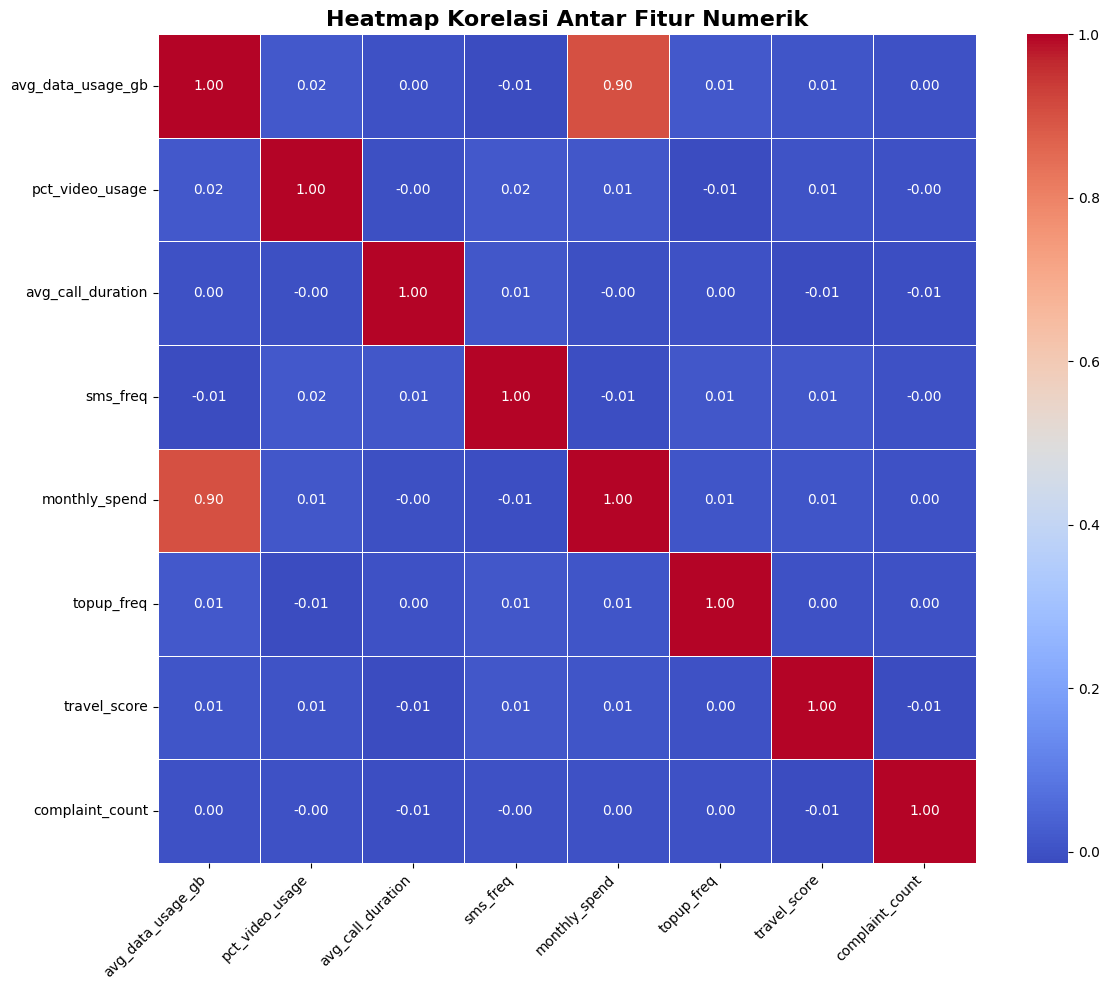

In [ ]:
# Membuat grafik heatmap untuk korelasi antar fitur numerik
# Hitung matriks korelasi
correlation_matrix = df[numerical_cols].corr()

# Buat heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Heatmap Korelasi Antar Fitur Numerik', fontsize=16, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

Heatmap ini menunjukkan korelasi antar fitur numerik dalam dataset.

Insight utama dari heatmap:
- Korelasi tertinggi ditemukan antara avg_data_usage_gb dan monthly_spend sebesar 0.90, menunjukkan bahwa semakin tinggi penggunaan data, semakin besar pengeluaran bulanan pengguna.
- pct_video_usage juga berkorelasi positif dengan avg_data_usage_gb, mengindikasikan bahwa konsumsi video berkontribusi besar terhadap total penggunaan data.
- complaint_count memiliki korelasi negatif lemah terhadap sebagian besar fitur, yang bisa berarti keluhan tidak terlalu dipengaruhi oleh perilaku penggunaan.
- Korelasi antar fitur lainnya relatif rendah hingga sedang, menunjukkan bahwa mereka menangkap aspek perilaku yang berbeda.


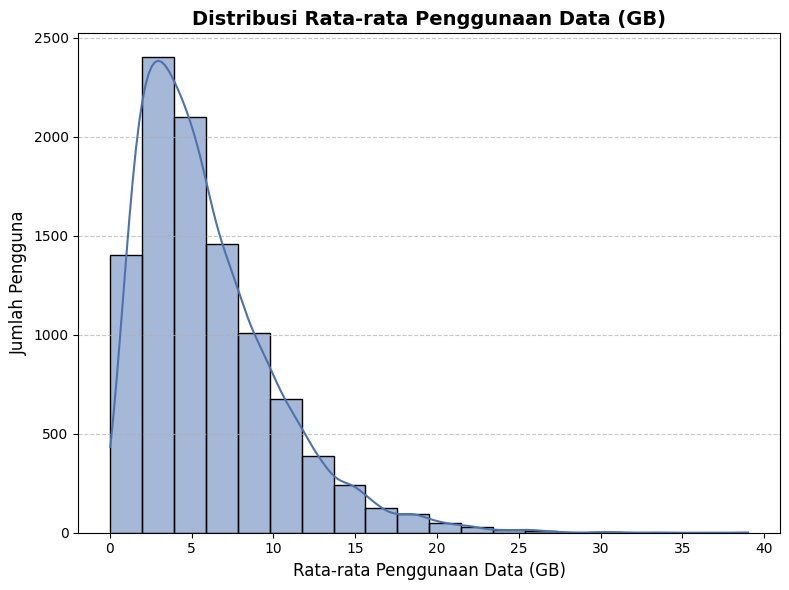

In [ ]:
# Histogram untuk distribusi rata-rata penggunaan data
plt.figure(figsize=(8, 6))
sns.histplot(df['avg_data_usage_gb'], bins=20, kde=True, color='#4C72B0')
plt.title('Distribusi Rata-rata Penggunaan Data (GB)', fontsize=14, fontweight='bold')
plt.xlabel('Rata-rata Penggunaan Data (GB)', fontsize=12)
plt.ylabel('Jumlah Pengguna', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

Visualisasi ini menunjukkan distribusi rata-rata penggunaan data oleh pengguna dalam satuan gigabyte (GB).

Insight utama:
- Sebagian besar pengguna memiliki rata-rata penggunaan data antara 0 hingga 10 GB, dengan puncak konsentrasi di sekitar 3–5 GB.
- Distribusi bersifat right-skewed, artinya hanya sedikit pengguna yang memiliki penggunaan data sangat tinggi.




In [ ]:
# Melihat kontribusi setiap fitur terhadap labelnya
# Membuat salinan X_train, y_train agar tidak mempengaruhi pipeline utama
X_analyzed = df.drop(columns=['target_offer', 'customer_id']).copy()
y_analyzed = df['target_offer'].copy()

# Melakukan label encoding untuk semua fitur kategorikal
for colname in X_analyzed.select_dtypes("object"):
    X_analyzed[colname], _ = X_analyzed[colname].factorize()

# Encode fitur target
y_analyzed, _ = pd.factorize(y_analyzed)

# Menentukan apakah setiap fitur sudah dianggap numerik untuk perhitungan MI
discrete_features = X_analyzed.dtypes == int

Secara garis besar, potongan kode tersebut digunakan untuk menyiapkan data sebelum dilakukan analisis kontribusi fitur terhadap target. Pertama, dibuat salinan data fitur dan label agar tidak mengganggu pipeline utama. Lalu, semua fitur kategorikal diubah menjadi bentuk numerik melalui proses encoding, begitu juga dengan label target. Setelah itu, ditentukan fitur mana yang dianggap diskrit berdasarkan tipe datanya. Dengan langkah-langkah ini, data menjadi siap untuk dihitung nilai Mutual Information sehingga bisa diketahui seberapa besar pengaruh masing-masing fitur terhadap target.


In [ ]:
# Fungsi untuk menghitung MI dan mengembalikan hasil berupa Series terurut
def make_mi_scores(X, y, discrete_features):
    mi_scores = mutual_info_classif(X, y, discrete_features=discrete_features)
    mi_scores = pd.Series(mi_scores, name="MI Scores", index=X.columns)
    mi_scores = mi_scores.sort_values(ascending=False)
    return mi_scores

# Hitung MI
mi_scores = make_mi_scores(X_analyzed, y_analyzed, discrete_features)
mi_scores[::]

,MI Scores
monthly_spend,0.429664
avg_data_usage_gb,0.317256
complaint_count,0.180238
pct_video_usage,0.172039
device_brand,0.099124
travel_score,0.053295
avg_call_duration,0.034145
plan_type,0.032942
sms_freq,0.030057
topup_freq,0.025189


Bagian kode ini digunakan untuk menghitung skor `Mutual Information (MI)` dari setiap fitur terhadap target. Fungsinya adalah untuk mengetahui seberapa besar kontribusi masing-masing fitur dalam memprediksi label.

Output dari perhitungan `Mutual Information` menunjukkan bahwa fitur yang paling berkontribusi terhadap target adalah monthly_spend dengan skor MI tertinggi, diikuti oleh avg_data_usage_gb dan complaint_count. Ini berarti fitur-fitur tersebut memiliki hubungan informasi yang paling kuat dengan label dan berpotensi menjadi prediktor utama dalam model. Fitur lain seperti topup_freq dan sms_freq memiliki skor rendah, menandakan kontribusi yang kecil terhadap target.


# Tahap 3 : Data Preprocessing

## 3.1 Mengubah Data Outlier yang Negatif Menjadi Positif

In [ ]:
# Ubah nilai nilai pada kolom yang negatif menjadi positif
df_cleaned = df.copy()
df_cleaned = df_cleaned.drop(columns=['customer_id'])
df_cleaned[['avg_call_duration','monthly_spend']] = df_cleaned[['avg_call_duration','monthly_spend']].abs()

Pada tahap data understanding sebelumnya, ditemukan adanya nilai negatif pada kolom numerik, khususnya avg_call_duration dan monthly_spend. Kedua kolom tersebut seharusnya tidak memiliki nilai kurang dari nol karena:

- avg_call_duration merepresentasikan durasi panggilan (menit), yang secara logis tidak bisa bernilai negatif.
- monthly_spend menunjukkan total pengeluaran pengguna, yang juga tidak mungkin bernilai negatif.

Untuk memperbaiki anomali tersebut, nilai negatif pada kedua kolom diubah menjadi nilai positif menggunakan fungsi `.abs()`. Dengan demikian, data menjadi lebih konsisten dan siap digunakan pada tahap preprocessing dan modeling.

## 3.2 Data Splitting

In [ ]:
# Melakukan splitting data
X = df_cleaned.drop(columns=['target_offer'])
y = df_cleaned['target_offer']

X_train, x_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42, shuffle = True, stratify=y)

Sebelum memasuki tahapan utama dalam proses data preprocessing, dataset dibagi terlebih dahulu menjadi dua bagian: data latih dan data uji. Pembagian dilakukan menggunakan fungsi `train_test_split` dengan proporsi 80% untuk data latih dan 20% untuk data uji. Parameter `shuffle=True` memastikan data diacak sebelum dipisah, sedangkan `stratify=y` menjaga agar distribusi label pada kedua subset tetap seimbang.  

Pemisahan dataset di awal bertujuan untuk mencegah kebocoran informasi dari data latih ke data uji. Seluruh proses data preprocessing akan dilakukan pada data training. Dengan demikian, performa model yang dihasilkan dapat dievaluasi secara objektif dan lebih mencerminkan kemampuan model ketika digunakan pada data baru.


## 3.4 Melihat Ketimpangan Data Pada Data Training

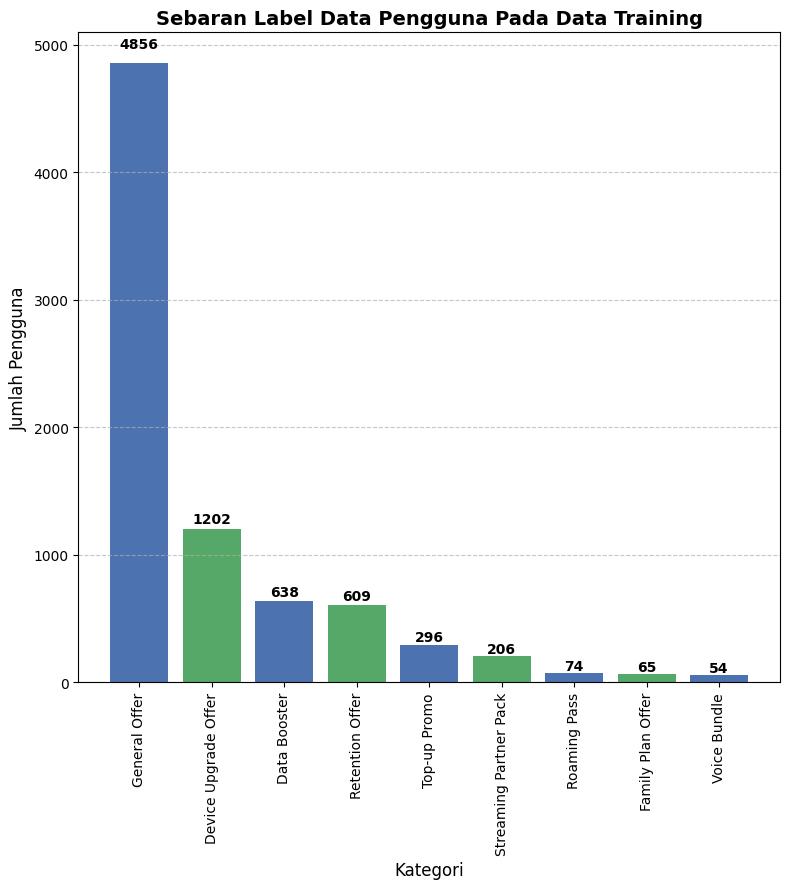

In [ ]:
# Menampilkan barplot untuk label dari pengguna pada data training
# Melihat sebaran label dari pengguna
value_counts = y_train.value_counts()

plt.figure(figsize=(8, 9))
bars = plt.bar(
    value_counts.index,
    value_counts.values,
    color=['#4C72B0', '#55A868']
)

plt.title('Sebaran Label Data Pengguna Pada Data Training', fontsize=14, fontweight='bold')
plt.xlabel('Kategori', fontsize=12)
plt.ylabel('Jumlah Pengguna', fontsize=12)
plt.xticks(rotation=90)
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Tambahkan angka di atas tiap batang
for bar in bars:
    yval = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        yval + (0.02 * yval),
        int(yval),
        ha='center', va='bottom', fontsize=10, fontweight='bold'
    )

plt.tight_layout()
plt.show()

Dari hasil grafik tersebut terlihat bahwa terdapat ketimpangan jumlah data pada setiap kelas `target_offer`. Ketidakseimbangan ini dapat memengaruhi proses training karena model cenderung belajar lebih banyak dari kelas yang jumlahnya paling besar. Akibatnya, model dapat menjadi bias dan menghasilkan prediksi yang lebih condong ke kelas mayoritas, sehingga performa pada kelas minoritas menjadi kurang akurat. Ini merupakan pola yang sama yang ditemukan pada saat data understanding, sehingga diperlukan metode penanganan data imbalanced tersebut.


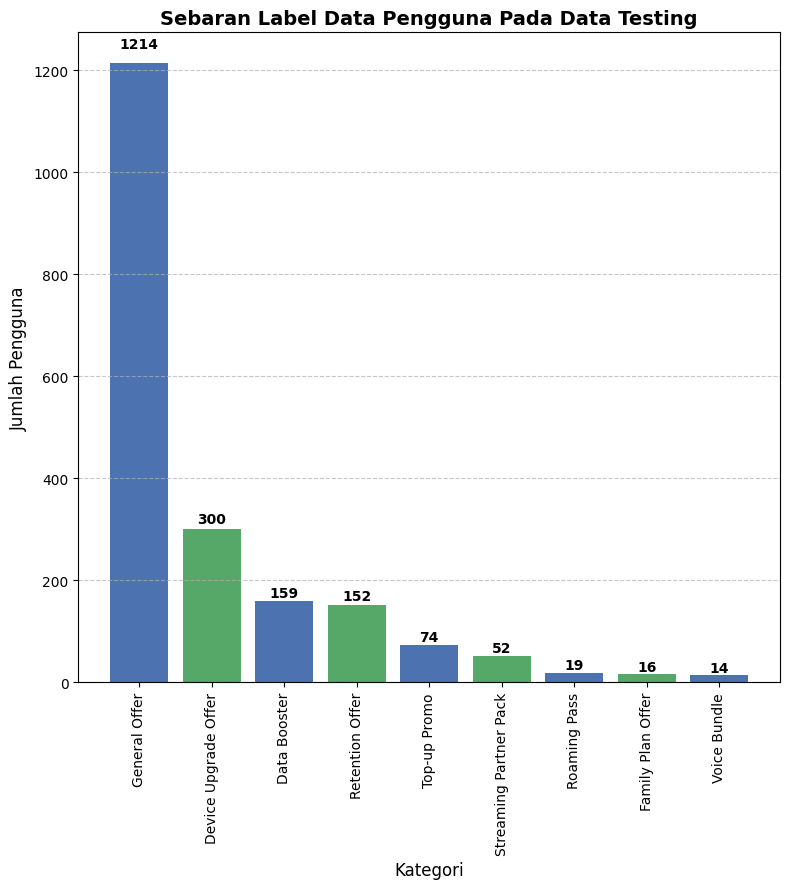

In [ ]:
# Menampilkan barplot untuk label dari pengguna data testing
# Melihat sebaran label dari pengguna
value_counts = y_test.value_counts()

plt.figure(figsize=(8, 9))
bars = plt.bar(
    value_counts.index,
    value_counts.values,
    color=['#4C72B0', '#55A868']
)

plt.title('Sebaran Label Data Pengguna Pada Data Testing', fontsize=14, fontweight='bold')
plt.xlabel('Kategori', fontsize=12)
plt.ylabel('Jumlah Pengguna', fontsize=12)
plt.xticks(rotation=90)
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Tambahkan angka di atas tiap batang
for bar in bars:
    yval = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        yval + (0.02 * yval),
        int(yval),
        ha='center', va='bottom', fontsize=10, fontweight='bold'
    )

plt.tight_layout()
plt.show()

Hal serupa juga ditemukan pada data testing, di mana distribusi kelasnya tetap tidak seimbang. Namun, pada data testing kondisi ini sengaja dibiarkan apa adanya karena data testing berfungsi sebagai representasi murni dari data dunia nyata yang tidak pernah dilihat oleh model. Dengan mempertahankan ketidakseimbangan tersebut, evaluasi performa model menjadi lebih realistis dan mencerminkan bagaimana model akan bekerja ketika diterapkan pada data aktual di lapangan.


## 3.5 Melakukan Encoding Data

In [ ]:
# Pastikan X_train Anda sudah dimuat
cat_cols = X_train.select_dtypes(include="object").columns
num_cols = X_train.select_dtypes(include=np.number).columns

preprocessor = ColumnTransformer(
    transformers=[
        # Gunakan OrdinalEncoder untuk encoding integer
        ('cat', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1), cat_cols),

        # StandardScaler untuk scaling numerik
        ('num', StandardScaler(), num_cols)
    ],
    remainder='passthrough'
)

X_train = preprocessor.fit_transform(X_train)
x_test = preprocessor.transform(x_test)

# Simpan dengan protokol stabil (protocol=4)
joblib.dump(preprocessor, 'preprocessor.joblib', compress=3, protocol=4)

['preprocessor.joblib']

Masuk ke dalam tahap berikutnya dari data preprocessing, pada tahap ini dilakukan preprocessing encoding dan standarisasi. Tujuan dari encoding adalah untuk mengkonversi data fitur kategorikal ke dalam numerik, hal ini dilakukan karena model Machine Learning hanya bisa menerima input numerik. Sedangkan tujuan dari scaling adalah membuat semua fitur data memiliki rentang numerik yang sama, sehingga tidak ada fitur yang dominan.

Untuk teknik encoding yang dipilih adalah `OrdinalEncoder` karena kami merasa teknik inilah yang paling cocok dan efisien untuk melakukan encode terhadap fitur fitur dataset yang digunakan untuk memprediksi target, `LabelEncoder` hanya cocok untuk fitur target, kemudian `OneHotEncoder` akan membuat dimensi data semakin besar, atas kedua alasan tersebut kami memutuskan untuk tidak menggunakan kedua teknik ini untuk encoding. Untuk resiko mengenai adanya urutan pada data, kami tidak melihat itu sebagai resiko karena model yang akan kami gunakan adalah model Tree-Based.

Kemudian untuk scaling kami memutuskan untuk menggunakan `StandardScaler` dengan alasan StandardScaler lebih fit untuk lebih banyak kondisi distribusi dataset ketimbang `MinMaxScaler`, kemudian setiap fitur juga memiliki rentang nilai yang berbeda beda sehingga kurang cocok jika menggunakan `MinMaxScaler`.

Dalam melakukan dua hal tersebut, kami membungkusnya dengan menggunakan `ColumnTransformer`, penggunaan `ColumnTransformer` lebih efisien secara komputasi program dibandingkan scaling dan normalisasi secara satu per satu.

Encoding dan scaling terlebih dahulu dipelajari dari data latih melalui proses fit, kemudian hasil pembelajaran tersebut diterapkan secara konsisten pada data testing melalui proses transform. Dengan demikian, data testing di-encode dan diskalakan menggunakan pola yang sudah dipelajari dari data latih, bukan dipelajari ulang, sehingga mencegah terjadinya data leakage dan menjaga konsistensi preprocessing.

Terakhir, simpan preprocessing dalam format joblib dengan nama "preprocessor.joblib" agar bisa di load kembali.

In [ ]:
# Encode pada y_train
y_encoder = LabelEncoder()
y_train = y_encoder.fit_transform(y_train)

# Eksport encoder
with open('encoder_label.joblib', 'wb') as f:
    joblib.dump(y_encoder, f, compress=3, protocol=4)

# Menampilkan hasil encoding pada y_train
y_train

array([3, 3, 6, ..., 3, 1, 1])

Setelah seluruh fitur pada variabel input (X) selesai di-encode, langkah berikutnya adalah melakukan encoding pada fitur target (y). Proses ini dilakukan menggunakan LabelEncoder, tetapi hanya diterapkan pada data latih (y_train). Pada tahap ini, encoder mempelajari seluruh kelas pada y_train (fit) dan kemudian mengonversinya menjadi nilai numerik (transform).

Tujuannya adalah sama seperti sebelumnya yaitu agar label yang semula berbentuk kategorikal dapat dibaca oleh model Machine Learning. Selain itu, melakukan encoding hanya pada y_train juga penting untuk menjaga konsistensi dan menghindari data leakage, karena kategori dan mapping label harus dipelajari murni dari data latih, bukan dari data testing.

In [ ]:
# Encode pada y_test
y_test = y_encoder.transform(y_test)

# Menampilkan hasil encoding pada y_train
y_test

array([3, 1, 3, ..., 1, 0, 3])

Pada tahap ini dilakukan proses encoding pada data target (y_test) menggunakan encoder yang sebelumnya telah dipelajari dari data latih.

In [ ]:
# Mengambil OrdinalEncoder dari preprocessor
ordinal_encoder = preprocessor.named_transformers_['cat']

# Menampilkan mapping kategori untuk setiap kolom kategorikal
print("Category Mappings from OrdinalEncoder:")
for i, col_name in enumerate(cat_cols):
    print(f"\n{col_name}:")
    for j, category in enumerate(ordinal_encoder.categories_[i]):
        print(f"  {category} -> {j}")
print(f"\n")

# Menampilkan mapping label untuk target (y)
print("Target Offer Label Mapping :")
for encoded_value, class_name in enumerate(y_encoder.classes_):
    print(f"  {class_name} -> {encoded_value}")

Category Mappings from OrdinalEncoder:

plan_type:
  Postpaid -> 0
  Prepaid -> 1

device_brand:
  Apple -> 0
  Huawei -> 1
  Oppo -> 2
  Realme -> 3
  Samsung -> 4
  Vivo -> 5
  Xiaomi -> 6


Target Offer Label Mapping :
  Data Booster -> 0
  Device Upgrade Offer -> 1
  Family Plan Offer -> 2
  General Offer -> 3
  Retention Offer -> 4
  Roaming Pass -> 5
  Streaming Partner Pack -> 6
  Top-up Promo -> 7
  Voice Bundle -> 8


Setelah proses encoding selesai, dilakukan pemeriksaan ulang terhadap hasil pemetaan kategori untuk melihat bagaimana setiap fitur kategorikal termasuk fitur target direpresentasikan dalam bentuk numerik oleh encoder.

## 3.6 Melakukan Oversampling Terhadap Kelas yang Mengalami Ketimpangan





In [ ]:
# Melakukan oversampling untuk kelas minoritas
smote = SMOTE(k_neighbors= 5, sampling_strategy= "auto", random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

Pada proses analisis sebelumnya, telah ditemukan pola dataset yang imbalanced, sehingga untuk menangani kasus ini kita bisa melakukan oversampling, alasan memilih oversampling ketimbang undersampling adalah karena mengingat imbalanced yang terjadi cukup parah maka data mayoritas yang akan dipotong akan sangat banyak, sehingga dapat membuat banyak informasi yang hilang. Atas alasan tersebut teknik oversampling lah yang paling cocok dengan kondisi dataset.

Teknik oversampling yang dipilih adalah `SMOTE` karena teknik `SMOTE` memiliki kelebihan yaitu membuat data sintetis berdasarkan data data disekitarnya bukan sekedar menduplikasi data yang ada, sehingga data lebih variatif.

Parameter yang dipilih untuk `SMOTE` ini pertama adalah `k_neighbors = 5` dimana data sintetis yang dibuat harus berdasarkan 5 data terdekatnya sehingga cukup bervariatif, kemudian `sampling_strategy` dimana `SMOTE` akan otomatis melakukan oversampling pada seluruh kelas yang jumlah datanya lebih sedikit daripada kelas mayoritas, sampai jumlahnya menjadi sama dengan kelas mayoritas.

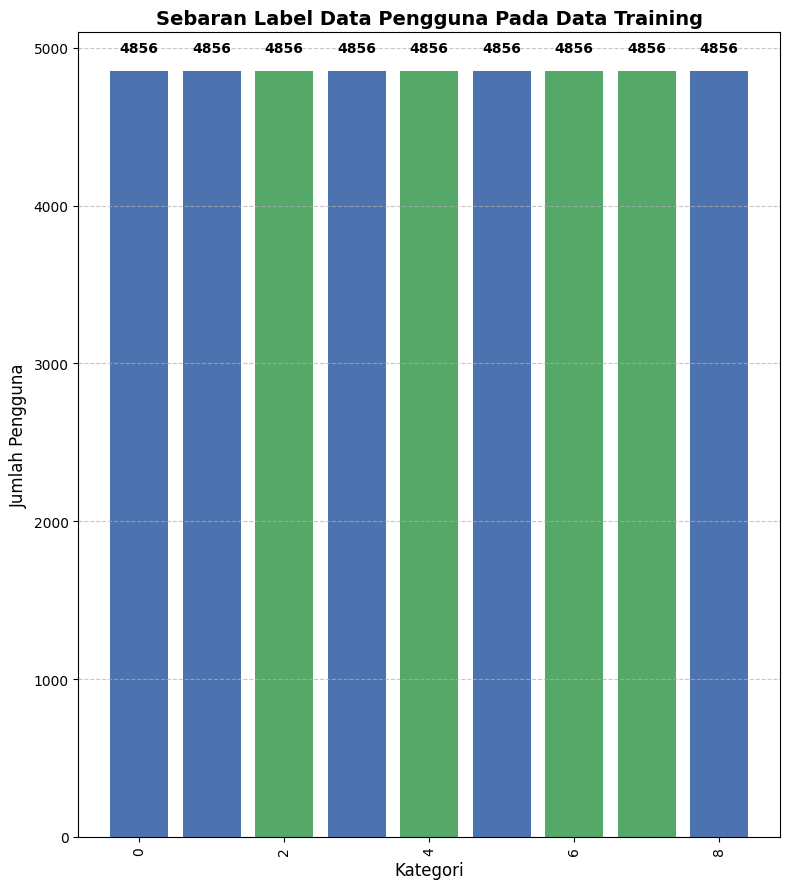

In [ ]:
# Menampilkan barplot untuk label dari pengguna pada data training
# Melihat sebaran label dari pengguna
value_counts = pd.Series(y_train_resampled).value_counts()

plt.figure(figsize=(8, 9))
bars = plt.bar(
    value_counts.index,
    value_counts.values,
    color=['#4C72B0', '#55A868']
)

plt.title('Sebaran Label Data Pengguna Pada Data Training', fontsize=14, fontweight='bold')
plt.xlabel('Kategori', fontsize=12)
plt.ylabel('Jumlah Pengguna', fontsize=12)
plt.xticks(rotation=90)
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Tambahkan angka di atas tiap batang
for bar in bars:
    yval = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        yval + (0.02 * yval),
        int(yval),
        ha='center', va='bottom', fontsize=10, fontweight='bold'
    )

plt.tight_layout()
plt.show()

Setelah dilakukan oversampling dengan metode `SMOTE` dapat dilihat bahwa kini data dari seluruh kategori sudah seimbang yaitu masing masing berjumlah 4856 data.

# Tahap 4 : Modelling
Setelah tahap data preprocessing selesai, waktunya untuk masuk ke babak baru yaitu Modelling, di mana pada tahap ini data yang sudah dipreprocessing dan dipisah menjadi data latih (training set) dan data uji (testing set) digunakan untuk membangun model Machine Learning.

Tujuan dari tahap modelling ini adalah:

1. Mempelajari pola dari data latih (X_train) agar model dapat mengenali hubungan antara fitur (X) dan target (y).

2. Memprediksi kelas target pada data baru (x_test) menggunakan pola yang telah dipelajari.

3. Mengevaluasi performa model untuk memastikan model mampu membuat prediksi yang akurat dan generalisasi dengan baik pada data yang belum pernah dilihat sebelumnya.

Melihat karakteristik dataset yang dimiliki, kami memutuskan untuk menggunakan model berbasis Tree-Based. Hal ini dikarenakan beberapa alasan:

1. Tahan terhadap data imbalanced Model tree-based seperti `Random Forest` atau `Gradient Boosting` cenderung lebih robust ketika jumlah sampel antar kelas tidak seimbang.

2. Mampu menangani fitur kategorikal Dengan encoding yang sudah dilakukan, tree-based model dapat memanfaatkan fitur kategorikal yang sudah diubah menjadi numerik tanpa menimbulkan bias besar.

Dengan pertimbangan tersebut, model tree-based dipilih agar dapat mengenali pola dari data latih secara optimal dan memberikan prediksi yang handal pada data uji, meskipun dataset memiliki karakteristik yang tidak ideal seperti imbalanced atau variasi nilai fitur yang berbeda-beda.

## 4.1 XGBOOST + RandomSearch

In [ ]:
# Model dasar
model_XGB = XGBClassifier(
    objective='multi:softprob',
    num_class=9,
    eval_metric='mlogloss',
    tree_method='hist',
    random_state=42
)

# Definisikan search space (pakai distribusi random)
param_dist = {
    "n_estimators": randint(50, 1000),
    "max_depth": randint(3, 8),
    "learning_rate": uniform(0.001, 0.3),
    "subsample": uniform(0.5, 0.5),
    "colsample_bytree": uniform(0.5, 0.5),
    "gamma": uniform(0, 5),
    "min_child_weight": randint(1, 15),
    "reg_alpha": uniform(1e-4, 1),
    "reg_lambda": uniform(1e-4, 1)
}

# Randomized Search
rand_search = RandomizedSearchCV(
    estimator=model_XGB,
    param_distributions=param_dist,
    n_iter=15,
    scoring='f1_macro',
    cv=3,
    verbose=1,
    n_jobs=-1,
    random_state=42
)

# Fit ke data training
rand_search.fit(X_train_resampled, y_train_resampled)

# Ambil model terbaik
best_model_XGB = rand_search.best_estimator_
print(rand_search.best_params_)

Fitting 3 folds for each of 15 candidates, totalling 45 fits
{'colsample_bytree': np.float64(0.6668543055695109), 'gamma': np.float64(0.7143340896097039), 'learning_rate': np.float64(0.19626654188465587), 'max_depth': 7, 'min_child_weight': 2, 'n_estimators': 393, 'reg_alpha': np.float64(0.8325426408004217), 'reg_lambda': np.float64(0.21243911067827614), 'subsample': np.float64(0.5909124836035503)}


Model pertama yang digunakan adalah `XGBoost`, yaitu algoritma gradient boosting berbasis pohon keputusan. `XGBoost` dipilih karena memiliki beberapa keunggulan teknis dibandingkan model tree-based umum seperti `Random Forest` atau `Decision Tree`:

- Membangun model secara bertahap (boosting) sehingga setiap pohon memperbaiki kesalahan pohon sebelumnya.  
- Memiliki regularisasi `L1` dan `L2`, sehingga model lebih tahan terhadap overfitting.  
- Mampu menangani pola yang kompleks serta bekerja sangat baik pada data tabular seperti dataset telekomunikasi.  

Untuk mendapatkan performa terbaik, digunakan `RandomizedSearchCV` sebagai teknik hyperparameter tuning. `Randomized Search` dipilih karena:

- Lebih efisien dibandingkan GridSearchCV maupun Bayesian Optimization, karena Random Search hanya melakukan sampling acak dari ruang parameter tanpa mengevaluasi seluruh kombinasi.
- Cocok digunakan ketika ruang parameter cukup luas, seperti `max_depth`, `gamma`, `learning_rate`, dan `n_estimators`.  
- Mampu menghasilkan model optimal lebih cepat dengan komputasi yang lebih rendah.

Proses tuning menggunakan `scoring='f1_macro'`, mengingat target label memiliki distribusi kelas yang tidak seimbang. F1-Macro memberikan penilaian yang adil terhadap seluruh kelas tanpa bias terhadap kelas mayoritas.

Model terbaik kemudian diperoleh dari hasil `RandomizedSearchCV` dan digunakan sebagai model utama untuk melakukan klasifikasi terhadap target_offer.


## 4.2 Random Forest + RandomSearchCV


In [ ]:
# Model dasar
model_rf = RandomForestClassifier(random_state = 42, n_jobs = -1)

# Definisikan search space (pakai distribusi random)
param_dist_RF = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2']
}

# Randomized Search
rand_search_RF = RandomizedSearchCV(
    estimator=model_rf,
    param_distributions=param_dist_RF,
    n_iter=15,
    scoring='f1_macro',
    cv=3,
    verbose=1,
    n_jobs=-1,
    random_state=42
)

# Fit ke data training
rand_search_RF.fit(X_train_resampled, y_train_resampled)

# Ambil model terbaik
best_model_RF = rand_search_RF.best_estimator_
print(rand_search_RF.best_params_)

Fitting 3 folds for each of 15 candidates, totalling 45 fits
{'n_estimators': 200, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': 'log2', 'max_depth': 30}


Kemudian model yang digunakan selanjutnya sebagai perbandingan adalah model `Random Forest` yang disertai dengan
hyperparameter tuning yang sama yaitu `Random Search`. Alasan pemilihan `Random Forest` sebagai model perbandingan adalah :

- Model ini cukup kuat dalam mengangani data tabular dan mampu untuk mepelajari pola non-linieritas dalam data.
- `Random Forest` juga merupakan model yang dapat membangun banyak pohon keputusan sehingga lebih stabil dibandingkan satu pohon tunggal.


Untuk meningkatkan performanya, dilakukan tuning menggunakan `RandomizedSearchCV` dengan ruang parameter yang mencakup `n_estimators`,`max_depth`,  `min_samples_split`, `min_samples_leaf`, `max_features`.


Seperti pada model sebelumnya, `RandomizedSearchCV` dipilih karena lebih efisien dibandingkan `Grid Search` ataupun `Bayesian` dan mampu menjelajahi kombinasi parameter secara acak dengan waktu komputasi yang lebih cepat.


Proses tuning kembali menggunakan `scoring='f1_macro'` untuk menjaga keadilan penilaian antar kelas, mengingat distribusi target yang tidak seimbang.


Model terbaik hasil `RandomizedSearchCV` kemudian digunakan sebagai model final `Random Forest` dalam proses klasifikasi target_offer.

# Tahap 5 : Evaluasi

Setelah tahap melatih model dengan data training telah selesai (modelling), tahap berikutnya adalah tahap menguji model dengan data yang tidak pernah dilihat atau disebut tahap evaluasi.

Tahap evaluasi ini bertujuan untuk melakukan pemeriksaan kualitas latihan yang dilakukan oleh model dari data training dengan menggunakan data testing.

Untuk tahapan evaluasi ini digunakan beberapa metriks seperti :

- **Accuracy**  
  Mengukur persentase prediksi yang benar dari keseluruhan data. Accuracy berguna untuk mengetahui performa model secara keseluruhan.

- **F1-Score**  
  Merupakan rata-rata dari precision dan recall. F1-score sangat berguna ketika distribusi kelas tidak seimbang, karena memberikan penilaian berdasarkan keseimbangan antara ketepatan dan kemampuan model menangkap sampel dari setiap kelas.

- **Classification Report**  
  Ringkasan metrik untuk setiap kelas, mencakup precision, recall, f1-score, dan support. Laporan ini membantu melihat performa model secara lebih rinci pada masing-masing kelas.

- **Confusion Matrix**  
  Tabel yang menunjukkan jumlah prediksi benar dan salah untuk setiap kelas. Matriks ini membantu mengidentifikasi pola kesalahan model.

Dengan menggunakan kombinasi metrik ini, evaluasi model dapat dilakukan secara lebih komprehensif, baik secara keseluruhan maupun pada performa masing-masing kelas.

## 5.1 Evaluasi XGBOOST + RandomSearch

In [ ]:
# Prediksi data training
y_pred_train_XGB = best_model_XGB.predict(X_train_resampled)

# Evaluasi prediksi data training
accuracy_XGB_train = accuracy_score(y_train_resampled, y_pred_train_XGB)
f1_XGB_train = f1_score(y_train_resampled, y_pred_train_XGB, average='macro')
clf_report_XGB_train = classification_report(y_train_resampled, y_pred_train_XGB)
cm_XGB_train = confusion_matrix(y_train_resampled, y_pred_train_XGB)

# Print hasil evaluasi model pada data training
print(f"Akurasi Training Model XGB: {accuracy_XGB_train:.4f}")
print(f"F1 Macro Training Model XGB: {f1_XGB_train:.4f}")

Akurasi Training Model XGB: 0.9995
F1 Macro Training Model XGB: 0.9995


Evaluasi model XGBoost pada data training dilakukan untuk melihat kemampuan model dalam mempelajari pola data. Proses dan hasilnya dapat diringkas sebagai berikut:

Model terbaik hasil tuning digunakan untuk melakukan prediksi pada seluruh data training.

Performa dievaluasi menggunakan metrik accuracy dan `F1-macro`, karena keduanya mampu memberikan gambaran keseluruhan dan keseimbangan antar kelas.

Hasil evaluasi menunjukkan:

- Accuracy Training: 0.9994

- F1-Macro Training: 0.9994

Nilai yang sangat tinggi mengindikasikan bahwa model sangat baik dalam mengenali pola data training.

Namun performa mendekati sempurna juga berpotensi menunjukkan overfitting, sehingga perlu dicek kembali hasilnya pada data testing.

Setelah melalui proses training

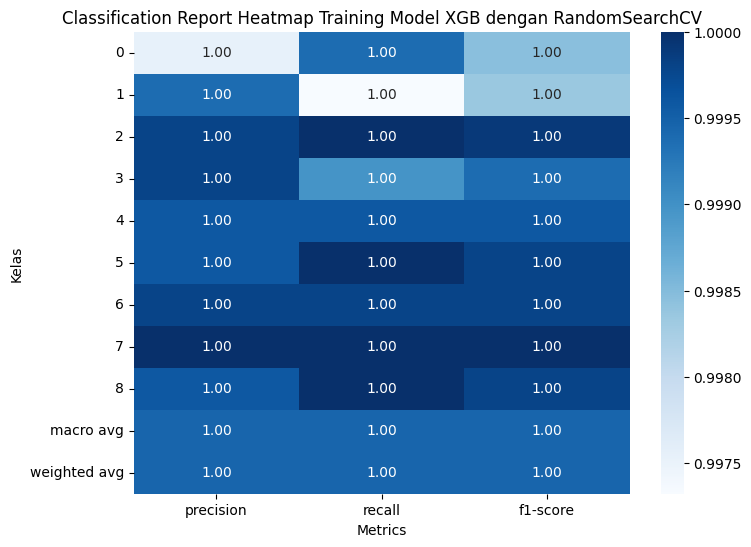

In [ ]:
# Grafik Classification Report
# Dapatkan classification report sebagai dictionary
report_dict_XGB_train = classification_report(y_train_resampled, y_pred_train_XGB, output_dict=True)

# Konversi ke DataFrame
report_df_XGB_train = pd.DataFrame(report_dict_XGB_train).transpose()

# Hapus baris 'accuracy' karena itu scalar
report_df_XGB_train = report_df_XGB_train.drop(index=['accuracy'])

# Plot heatmap
plt.figure(figsize=(8,6))
sns.heatmap(report_df_XGB_train.iloc[:,:3], annot=True, cmap='Blues', fmt=".2f")
plt.title("Classification Report Heatmap Training Model XGB dengan RandomSearchCV")
plt.ylabel("Kelas")
plt.xlabel("Metrics")
plt.show()

Visualisasi classification report pada data training menggunakan heatmap dilakukan untuk melihat performa model XGBoost secara lebih intuitif. Ringkasan proses dan hasilnya sebagai berikut:

- Classification report dikonversi menjadi DataFrame agar dapat divisualisasikan dalam bentuk heatmap.

- Tiga metrik utama yang ditampilkan adalah precision, recall, dan f1-score untuk setiap kelas.

- Baris accuracy dihapus karena bersifat scalar dan tidak relevan untuk heatmap berbasis kelas.

- Heatmap menunjukkan bahwa seluruh kelas mendapatkan nilai mendekati 1.00 pada semua metrik.

- Warna biru tua yang dominan menandakan performa model sangat baik pada data training.

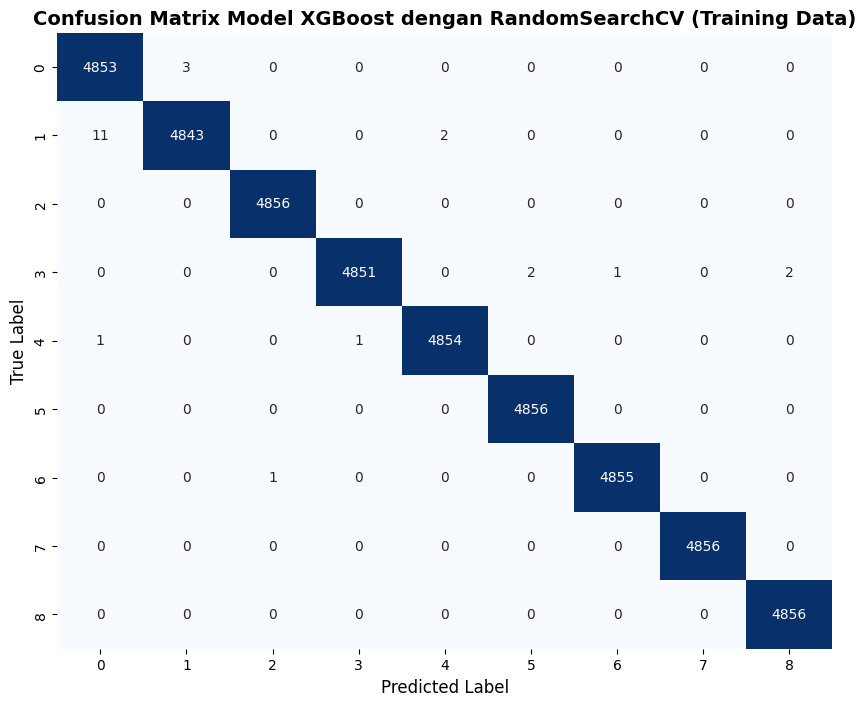

In [ ]:
# Grafik confussion matriks untuk model XGBoost dengan RandomSearchCV
plt.figure(figsize=(10, 8))
sns.heatmap(cm_XGB_train, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title('Confusion Matrix Model XGBoost dengan RandomSearchCV (Training Data)', fontsize=14, fontweight='bold')
plt.xlabel('Predicted Label', fontsize=12)
plt.ylabel('True Label', fontsize=12)
plt.show()

Confusion matrix untuk model XGBoost pada data training menunjukkan performa prediksi model setelah proses training dan tuning. Ringkasannya sebagai berikut:

- Mayoritas nilai berada tepat pada diagonal utama, menandakan hampir semua sampel berhasil diprediksi dengan benar.

- Setiap kelas memiliki jumlah prediksi benar yang sangat tinggi, rata-rata lebih dari 4.850 sampel per kelas.

- Kesalahan prediksi sangat kecil dan hanya muncul pada beberapa kelas, contohnya:

  - Kelas 0 → ada 3 prediksi salah ke kelas 1

  - Kelas 1 → beberapa sampel salah ke kelas 0 dan kelas 4

  - Kelas 3 → sedikit salah prediksi ke kelas 4, 6, dan 7

  - Kelas 6 → 1 sampel salah diprediksi sebagai kelas 2

- Jumlah kesalahan ini sangat kecil dibandingkan total sampel tiap kelas sehingga menandakan model mampu mempelajari pola data training dengan sangat baik.

- Pola ini konsisten dengan metrik sebelumnya yang menunjukkan performa mendekati sempurna (accuracy dan F1-macro = 0.9994).



In [ ]:
# Prediksi data testing
y_pred_test_XGB = best_model_XGB.predict(x_test)

# Evaluasi prediksi data testing
accuracy_XGB_test = accuracy_score(y_test, y_pred_test_XGB)
f1_XGB_test = f1_score(y_test, y_pred_test_XGB, average='macro')
clf_report_XGB_test = classification_report(y_test, y_pred_test_XGB)
cm_XGB_test = confusion_matrix(y_test, y_pred_test_XGB)

# Print hasil evaluasi model pada data testing
print(f"Akurasi Testing: {accuracy_XGB_test:.4f}")
print(f"F1 Macro Testing: {f1_XGB_test:.4f}")

Akurasi Testing: 0.9945
F1 Macro Testing: 0.9769


Evaluasi pada data testing dilakukan untuk melihat kemampuan model XGBoost dalam melakukan generalisasi pada data yang belum pernah dilihat sebelumnya. Ringkasannya sebagai berikut:

- Model digunakan untuk memprediksi label pada seluruh sampel data testing.

- Dua metrik utama digunakan untuk menilai performa:

  - Accuracy =  melihat persentase prediksi benar secara keseluruhan.

  - F1-Macro =  menilai keseimbangan performa per kelas, terutama penting untuk data tidak seimbang.

- Hasil evaluasi menunjukkan:

  - Accuracy Testing: 0.9945

  - F1-Macro Testing: 0.9769

- Akurasi yang sangat tinggi menunjukkan model mampu mempertahankan performa baik pada data baru.

- Penurunan F1-Macro dibandingkan data training menandakan adanya sedikit gap, namun masih dalam kategori sangat baik.  

Secara keseluruhan, performa model tetap kuat dan generalisasi tergolong sangat baik.

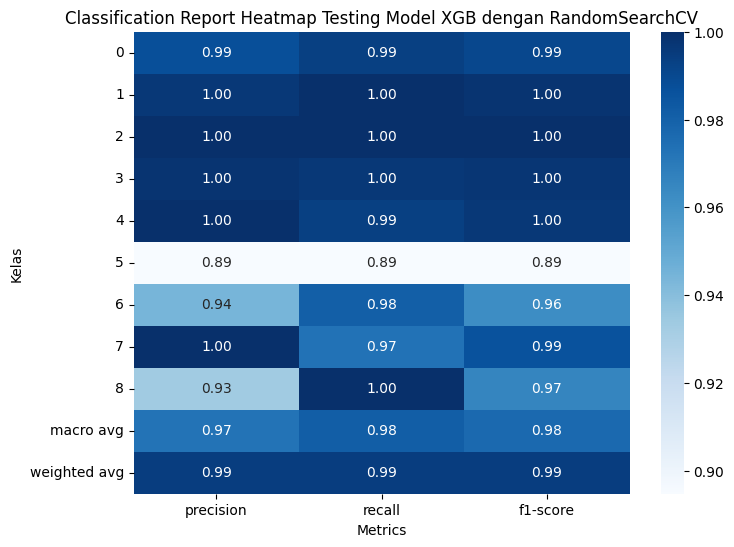

In [ ]:
# Grafik Classification Report
# Dapatkan classification report sebagai dictionary
report_dict_XGB_test = classification_report(y_test, y_pred_test_XGB, output_dict=True)

# Konversi ke DataFrame
report_df_XGB_test = pd.DataFrame(report_dict_XGB_test).transpose()

# Hapus baris 'accuracy' karena itu scalar
report_df_XGB_test = report_df_XGB_test.drop(index=['accuracy'])

# Plot heatmap
plt.figure(figsize=(8,6))
sns.heatmap(report_df_XGB_test.iloc[:,:3], annot=True, cmap='Blues', fmt=".2f")
plt.title("Classification Report Heatmap Testing Model XGB dengan RandomSearchCV")
plt.ylabel("Kelas")
plt.xlabel("Metrics")
plt.show()

Visualisasi classification report pada data testing menggunakan heatmap bertujuan untuk memudahkan analisis performa model XGBoost pada masing-masing kelas secara lebih intuitif. Ringkasan proses dan interpretasinya adalah sebagai berikut:

- Classification report dikonversi menjadi DataFrame sehingga dapat divisualisasikan dalam bentuk heatmap.

- Tiga metrik utama ditampilkan pada visualisasi, yaitu: precision, recall, dan f1-score untuk setiap kelas.

- Baris accuracy dihapus karena bukan metrik per kelas, sehingga tidak relevan untuk visualisasi ini.

- Hasil heatmap menunjukkan sebagian besar kelas memperoleh skor yang sangat tinggi mendekati 1.00 pada seluruh metrik.

- Warna biru tua mendominasi heatmap menandakan performa model sangat kuat dan konsisten dalam mengklasifikasi data testing.

Kelas tertentu seperti kelas 5 dan 8 memiliki nilai sedikit lebih rendah dibanding kelas lain, menandakan masih ada tantangan dalam membedakan kelas tersebut, namun performanya tetap dalam kategori sangat baik.

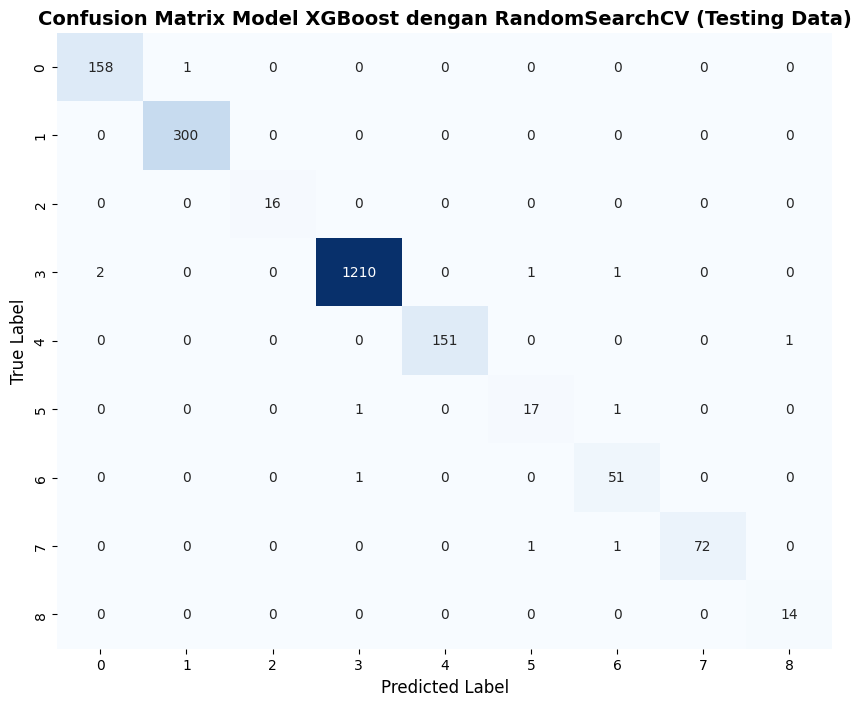

In [ ]:
# Grafik confussion matriks untuk model XGBoost dengan RandomSearchCV
plt.figure(figsize=(10, 8))
sns.heatmap(cm_XGB_test, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title('Confusion Matrix Model XGBoost dengan RandomSearchCV (Testing Data)', fontsize=14, fontweight='bold')
plt.xlabel('Predicted Label', fontsize=12)
plt.ylabel('True Label', fontsize=12)
plt.show()

Confusion matrix digunakan untuk melihat detail kesalahan dan keberhasilan prediksi model pada setiap kelas. Visualisasi ini membantu memahami kelas mana yang diprediksi dengan baik dan kelas mana yang masih membingungkan bagi model.

Ringkasan proses dan temuan dari hasil visualisasi:

- Sumbu vertikal menunjukkan label asli (true label), sementara sumbu horizontal menunjukkan label hasil prediksi (predicted label).

- Kotak diagonal utama menunjukkan jumlah sampel yang berhasil diprediksi dengan benar oleh model.

- Hampir semua nilai berada pada diagonal yang menunjukkan bahwa model sangat akurat dalam membedakan setiap kelas.

- Sedikit kesalahan prediksi terjadi pada beberapa kelas:

  - Kelas 3 dan 7 memiliki sedikit misclassifications ke kelas lain.

  - Kelas 5 dan 8 juga menunjukkan jumlah prediksi yang tidak sempurna, namun tetap tergolong sangat kecil dibanding jumlah total data.

Tidak ada kelas yang mengalami misclassifications besar, yang berarti tidak ada kelas yang benar-benar membingungkan bagi model.

In [ ]:
# Melakukan cross-validation untuk melihat skor model secara adil
cross_val_score(best_model_XGB, X_train_resampled , y_train_resampled, cv=5, scoring='f1_macro')

array([0.99678953, 0.99794101, 0.99839856, 0.99851262, 0.99862624])

Cross-validation dilakukan untuk memastikan bahwa performa model tidak hanya tinggi pada satu subset data saja, namun konsisten di seluruh bagian data. Metode yang digunakan adalah 5-Fold Cross Validation, di mana data pelatihan dibagi menjadi 5 bagian, dan model dilatih serta diuji secara bergantian pada tiap fold.

Insight :

- Seluruh skor cross-validation berada di atas 0.99, menunjukkan performa model yang sangat stabil.

- Variasi antar fold sangat kecil =  model tidak mengalami overfitting berarti terhadap data tertentu.

- F1-Macro dipilih karena memberikan evaluasi lebih adil pada data dengan distribusi kelas yang tidak seimbang.

## 5.2 Evaluasi Random Forest + RandomSearchCV

In [ ]:
# Prediksi data training
y_pred_train_RF = best_model_RF.predict(X_train_resampled)

# Evaluasi prediksi data training
accuracy_RF_train = accuracy_score(y_train_resampled, y_pred_train_RF)
f1_RF_train = f1_score(y_train_resampled, y_pred_train_RF, average='macro')
clf_report_RF_train = classification_report(y_train_resampled, y_pred_train_RF)
cm_RF_train = confusion_matrix(y_train_resampled, y_pred_train_RF)

# Print hasil evaluasi model pada data training
print(f"Akurasi Training Model Random Forest: {accuracy_RF_train:.4f}")
print(f"F1 Macro Training Model Random Forest: {f1_RF_train:.4f}")

Akurasi Training Model Random Forest: 1.0000
F1 Macro Training Model Random Forest: 1.0000


Model Random Forest diuji terlebih dahulu pada data training untuk melihat seberapa baik model mempelajari pola pada data yang digunakan selama proses pelatihan.

Dua metrik utama yang digunakan adalah:

- Accuracy = Persentase prediksi yang benar dari seluruh sampel.

- F1-Macro = Mengukur keseimbangan performa tiap kelas, terutama pada dataset dengan ketidakseimbangan jumlah sampel.

Intepretasi:
- Performa model pada data training sempurna di semua kelas.

- Menunjukkan bahwa model benar-benar mempelajari pola dari data pelatihan dengan sangat baik.

Nilai sempurna seperti ini dapat menjadi indikasi awal adanya potensi overfitting, sehingga kami perlu membandngkan dengan performa pada data testing.

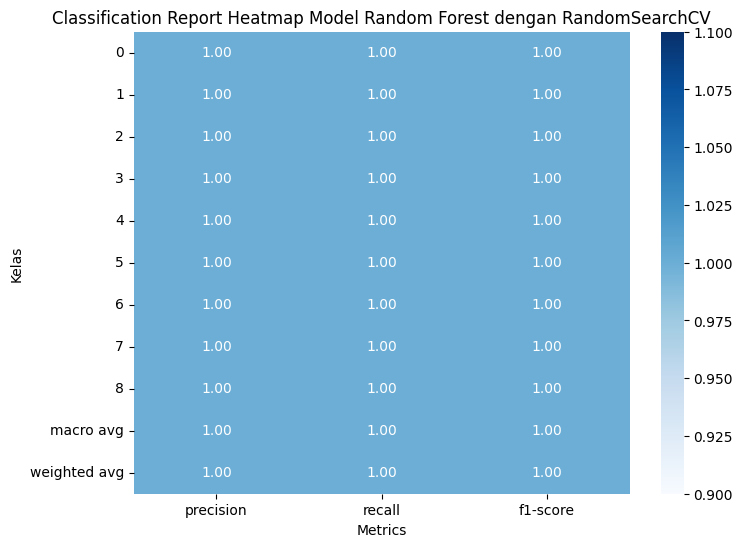

In [ ]:
# Grafik Classification Report
# Dapatkan classification report sebagai dictionary
report_dict_RF_train = classification_report(y_train_resampled, y_pred_train_RF, output_dict=True)

# Konversi ke DataFrame
report_df_RF_train = pd.DataFrame(report_dict_RF_train).transpose()

# Hapus baris 'accuracy' karena itu scalar
report_df_RF_train = report_df_RF_train.drop(index=['accuracy'])

# Plot heatmap
plt.figure(figsize=(8,6))
sns.heatmap(report_df_RF_train.iloc[:,:3], annot=True, cmap='Blues', fmt=".2f")
plt.title("Classification Report Heatmap Model Random Forest dengan RandomSearchCV")
plt.ylabel("Kelas")
plt.xlabel("Metrics")
plt.show()

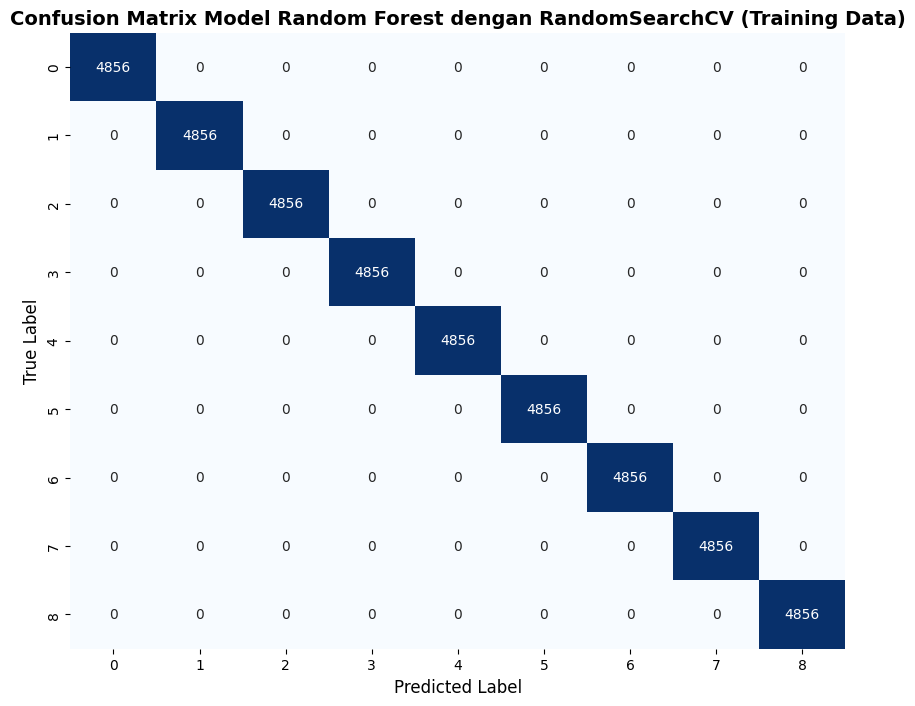

In [ ]:
# Grafik confussion matriks untuk model Random Forest dengan RandomSearchCV
plt.figure(figsize=(10, 8))
sns.heatmap(cm_RF_train, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title('Confusion Matrix Model Random Forest dengan RandomSearchCV (Training Data)', fontsize=14, fontweight='bold')
plt.xlabel('Predicted Label', fontsize=12)
plt.ylabel('True Label', fontsize=12)
plt.show()

In [ ]:
# Prediksi data testing
y_pred_test_RF = best_model_RF.predict(x_test)

# Evaluasi prediksi data testing
accuracy_RF_test = accuracy_score(y_test, y_pred_test_RF)
f1_RF_test = f1_score(y_test, y_pred_test_RF, average='macro')
clf_report_RF_test = classification_report(y_test, y_pred_test_RF)
cm_RF_test = confusion_matrix(y_test, y_pred_test_RF)

# Print hasil evaluasi model pada data testing
print(f"Akurasi Testing: {accuracy_RF_test:.4f}")
print(f"F1 Macro Testing: {f1_RF_test:.4f}")

Akurasi Testing: 0.9870
F1 Macro Testing: 0.9474


Setelah model menunjukkan performa sempurna pada data training, pengujian dilanjutkan pada data testing untuk melihat kemampuan model dalam melakukan generalisasi pada data yang belum pernah dilihat sebelumnya.

Dua metrik utama digunakan:

- Accuracy = Mengukur keseluruhan ketepatan prediksi.

- F1-Macro = Mengukur keseimbangan performa di setiap kelas, terutama ketika dataset tidak seimbang.

Interpretasi:
- Meskipun lebih rendah dibanding nilai pada data training, performa model tetap berada pada kategori sangat baik.

- Penurunan F1-Macro dibandingkan training mengindikasikan model cenderung overfitting, yaitu terlalu menyesuaikan diri pada data pelatihan.

Namun, nilai hampir mendekati 1.00 menunjukkan model masih sangat efektif dalam memprediksi label pada data baru.

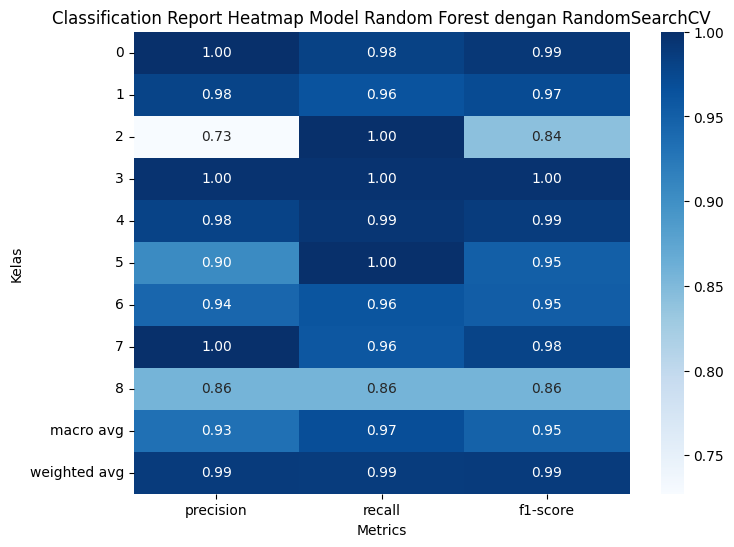

In [ ]:
# Grafik Classification Report
# Dapatkan classification report sebagai dictionary
report_dict_RF_test = classification_report(y_test, y_pred_test_RF, output_dict=True)

# Konversi ke DataFrame
report_df_RF_test = pd.DataFrame(report_dict_RF_test).transpose()

# Hapus baris 'accuracy' karena itu scalar
report_df_RF_test = report_df_RF_test.drop(index=['accuracy'])

# Plot heatmap
plt.figure(figsize=(8,6))
sns.heatmap(report_df_RF_test.iloc[:,:3], annot=True, cmap='Blues', fmt=".2f")
plt.title("Classification Report Heatmap Model Random Forest dengan RandomSearchCV")
plt.ylabel("Kelas")
plt.xlabel("Metrics")
plt.show()

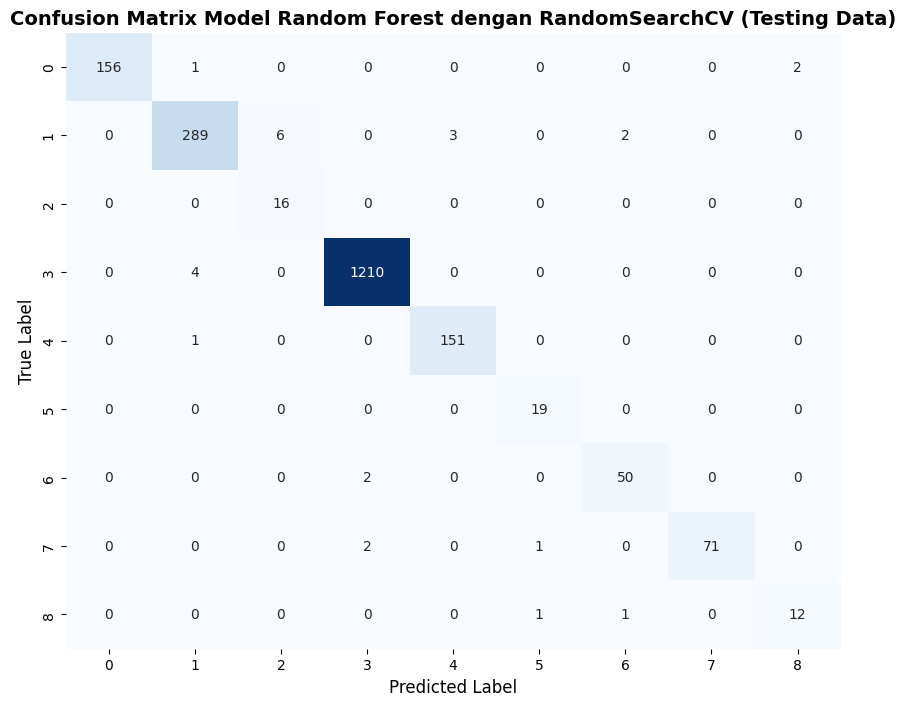

In [ ]:
# Grafik confussion matriks untuk model Random Forest dengan RandomSearchCV
plt.figure(figsize=(10, 8))
sns.heatmap(cm_RF_test, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title('Confusion Matrix Model Random Forest dengan RandomSearchCV (Testing Data)', fontsize=14, fontweight='bold')
plt.xlabel('Predicted Label', fontsize=12)
plt.ylabel('True Label', fontsize=12)
plt.show()

Confusion matrix digunakan untuk melihat performa model Random Forest pada data testing secara lebih detail. Ringkasan hasilnya adalah sebagai berikut:

- Visualisasi menampilkan jumlah prediksi benar dan salah untuk setiap kelas.

- Sebagian besar nilai berada pada diagonal utama, menandakan model mampu mengklasifikasikan banyak sampel dengan benar.

- Kelas dengan jumlah sampel besar seperti kelas 3 dan 4 menunjukkan prediksi yang sangat akurat.

- Beberapa kesalahan prediksi terjadi pada kelas dengan sampel kecil, misalnya:

  - kelas 1 salah diprediksi sebagai kelas 2 dan 4.

  - Kelas 6 ada yang diprediksi menjadi kelas 3.

  - Kelas 7 memiliki sedikit kesalahan prediksi terhadap kelas 3.

Kesalahan tersebut masih tergolong kecil dibandingkan prediksi benar, menandakan model memiliki performa generalisasi yang cukup baik. Pola pada confusion matrix menunjukkan bahwa Random Forest bekerja stabil meskipun terdapat kelas tertentu yang lebih sulit dibedakan.

In [ ]:
# Melakukan cross-validation untuk melihat skor model secara adil
cross_val_score(best_model_RF, X_train_resampled , y_train_resampled, cv=5, scoring='f1_macro')

array([0.99439228, 0.99736364, 0.99885664, 0.99828177, 0.99851111])

# Tahap 6 : Menyimpan model dengan performa terbaik

Model yang disimpan adalah model dengan menggunakan algoritma XGBoost yang disertai dengan RandomSearchCV karena dari statistik score hasil evaluasi, model ini mampu menunjukkan score terbaik dibandingkan model lainnya

## 6.1 Menyimpan Model dengan Format Joblib

In [ ]:
# Menyimpan model ke dalam format joblib
joblib.dump(best_model_XGB, 'model.joblib', compress=3, protocol=4)
print("Model 'model.joblib' berhasil disimpan.")

Model 'model.joblib' berhasil disimpan.


Lakukan penyimpanan model dalam format joblib menggunakan parameter compress = 3 dan protocol = 4, di mana compress = 3 berfungsi untuk mengompresi file agar ukuran model menjadi lebih kecil, sedangkan protocol = 4 digunakan untuk memastikan format penyimpanan tetap kompatibel dengan berbagai versi Python.

# Tahap 7 : Inferensi Model

Setelah model, preprocessor, dan encoder label disimpan dalam format joblib, langkah selanjutnya adalah melakukan inferensi. Tahap ini bertujuan untuk menguji apakah ketiga komponen tersebut dapat dimuat kembali dan digunakan dengan benar untuk memproses data input baru serta menghasilkan prediksi label yang sesuai.

## 7.1 Melakukan Load Komponen Komponen Preprocessing Serta Model yang Telah Disimpan

In [ ]:
# Load preprocessor.joblib untuk encoding dan scaling
with open('preprocessor.joblib', 'rb') as f:
    loaded_preprocessor = joblib.load(f)

# Load encoder_label.joblib yang berfungsi untuk melakukan encoding terhadap hasil label prediksi
with open('encoder_label.joblib', 'rb') as f:
    loaded_y_encoder = joblib.load(f)

# Load model.joblib yang berfungsi untuk melakukan prediksi label terhadap data input
with open('model.joblib', 'rb') as f:
    loaded_model_XGB = joblib.load(f)

print("Komponen preprocessing dan model telah berhasil di load")

Komponen preprocessing dan model telah berhasil di load


Pada tahap ini dilakukan proses load terhadap komponen-komponen yang dibutuhkan untuk inferensi, yaitu preprocessor untuk melakukan preprocessing pada data input, encoder_label untuk melakukan inverse label hasil prediksi, serta model yang digunakan untuk menghasilkan prediksi akhir.

## 7.2 Membuat Fungsi Preprocessing Data Input

In [ ]:
# Membuat fungsi preprocessing data baru untuk inferensi model
def preprocess_new_data(
    plan_type,
    device_brand,
    avg_data_usage_gb,
    pct_video_usage,
    avg_call_duration,
    sms_freq,
    monthly_spend,
    topup_freq,
    travel_score,
    complaint_count
):

    # Membuat DataFrame dari data baru yang akan diprediksi
    new_data = pd.DataFrame({
        'plan_type': [plan_type],
        'device_brand': [device_brand],
        'avg_data_usage_gb': [avg_data_usage_gb],
        'pct_video_usage': [pct_video_usage],
        'avg_call_duration': [avg_call_duration],
        'sms_freq': [sms_freq],
        'monthly_spend': [monthly_spend],
        'topup_freq': [topup_freq],
        'travel_score': [travel_score],
        'complaint_count': [complaint_count]
    })

    # Mengubah nilai menjadi absolut pada kolom tertentu
    if 'avg_call_duration' in new_data.columns:
        new_data['avg_call_duration'] = new_data['avg_call_duration'].abs()
    if 'monthly_spend' in new_data.columns:
        new_data['monthly_spend'] = new_data['monthly_spend'].abs()

    # Menerapkan preprocessor (ColumnTransformer) pada data baru
    # loaded_preprocessor.transform akan mengembalikan numpy array
    processed_data = loaded_preprocessor.transform(new_data)


    return processed_data

Pada bagian ini dibuat sebuah fungsi untuk melakukan preprocessing data baru menggunakan langkah yang sama seperti saat melatih model. Fungsi ini memanfaatkan preprocessor yang telah di load sebelumnya untuk memastikan transformasi data input tetap konsisten sebelum dilakukan prediksi oleh model.

## 7.3 Membuat Data Baru Sebagai Input Untuk Inferensi Model

In [ ]:
# Membuat data sampel baru untuk inferensi
new_sample_data = preprocess_new_data(
    plan_type='Prepaid',
    device_brand='Samsung',
    avg_data_usage_gb=5.5,
    pct_video_usage=0.5,
    avg_call_duration=10.0,
    sms_freq=15,
    monthly_spend=58000.0,
    topup_freq=3,
    travel_score=0.3,
    complaint_count=1
)

# Melakukan prediksi menggunakan model XGB hasil tuning yang sudah dimuat
prediction_XGB_loaded = loaded_model_XGB.predict(new_sample_data)
predicted_offer_XGB_loaded = loaded_y_encoder.inverse_transform(prediction_XGB_loaded)

# Menampilkan hasil prediksi oleh model
print("\nPrediksi untuk Data Baru")
print(f"Prediksi Offer (XGB + RandomSearch): {predicted_offer_XGB_loaded[0]}")


Prediksi untuk Data Baru
Prediksi Offer (XGB + RandomSearch): Top-up Promo


Setelah membuat fungsi preprocessing untuk data input, tahap selanjutnya adalah menguji model menggunakan data sampel baru. Pertama, dibuat sebuah data sampel dengan format yang sama seperti data training maupun testing. Data tersebut kemudian dimasukkan ke dalam fungsi preprocessing yang telah dibuat agar diproses menggunakan tahapan preprocessing yang sama dengan saat proses pelatihan. Hasil preprocessing selanjutnya digunakan sebagai input untuk model XGBoost yang telah diload guna menghasilkan prediksi, dan output numerik dari model dikonversi kembali ke label asli menggunakan encoder_label.

# Kesimpulan Akhir

Model yang dibangun menunjukkan performa yang sangat baik, ditunjukkan oleh skor evaluasi berikut:

- Accuracy Training: 0.9994

- F1-Macro Training: 0.9994

- Accuracy Testing: 0.9945

- F1-Macro Testing: 0.9769

Hasil ini menunjukkan bahwa model mampu mempelajari pola data dengan sangat baik pada data latih sekaligus tetap menggeneralisasi dengan baik pada data uji, tanpa gejala overfitting yang signifikan.

Selain itu, hasil prediksi pada data sampel menunjukkan bahwa model berhasil memberikan label yang tepat. Hal ini karena data inferensi yang digunakan memiliki karakteristik yang selaras dengan profil label Top-up Promo, sehingga prediksi yang dihasilkan konsisten dengan ekspektasi.

Dengan performa yang tinggi dan hasil inferensi yang sesuai, dapat disimpulkan bahwa model beserta seluruh komponen preprocessing-nya sudah siap digunakan untuk proses deployment.